# 0DTE nearest-OTM straddle, $t\to T$ (hold to official close)

This notebook is **not** the 30-min re-pick
(`atm_straddle_intraday.ipynb`) and **not** only the last-30-min trade
(15:30→close). At every clock $t\in\{10{:}00,\ldots,15{:}30\}$ it picks the
nearest-OTM straddle and holds **those** $K$ to cash settlement vs
`^GSPC` close. Twelve overlapping $t\to T$ trades per day. The 15:30
row **is** the last-30-min trade. Every straddle is **delta-hedged** in the index every
30 minutes to the close (§4b says exactly how).

## Choice 1 — instrument

| | **This notebook** ($t\to T$) | Re-pick ($t\to t{+}30$) |
|---|---|---|
| strikes | new nearest-OTM at $t$, keep $K$ until close | new nearest-OTM at $t$, exit next mid |
| $R_t$ | cash-settle vs official close / entry $-1$ | next mid of the $t$-straddle / entry $-1$ |
| implied pairing | remaining $\mathrm{IV}^{2}h_t$ vs remaining RV | $w_t\mathrm{IV}^{2}h_t$ vs next-bar $\widehat{RV}$ |

$\mathrm{sign}(s)$ is the same as the re-pick book ($s^{\mathrm{m}}=w\cdot s_{\mathrm{rem}}$). The **payoff** is not.

## No-peek protocol

Every position-forming quantity at bar $t$ is one of two things: the
bar's **own entry quote** (the tradable price at decision time), or
an estimate built **strictly from prior days, lagged at least one
day** — the smear's $(a,b,\hat\sigma^2)$, the diurnal profile $w$,
the per-clock leverage medians. Realized exits enter only as
outcomes, never as inputs. No quantity differences two quotes taken
at different times: that construction (the implied-decay $\Delta V$)
embeds the later quote's view of the bar it brackets, and is
confined to parked studies. By construction a perturbation of
day-$d$ inputs cannot move a day-$d$ estimate; it registers on day
$d{+}1$.

The construction was re-audited after the bar-end alignment fix (the
forecast panel is bar-end labelled, so trade bar $t$ joins the row
stamped $t{+}30$ min): perturbing the joined row's realized variance,
whole days and single rows, leaves every same-day position unchanged.
The join-shift diagnostic for the close trade, which places the fresh
join on a smooth staleness curve and shows the jump one bar of actual
lookahead produces, lives in the RV–IV notebook and is not repeated
here. Upstream, `baseline` is a strictly-prior-days per-clock
estimator and every forecast feature carries the one-bar shift.

## Choice 2 — IV (same window as $\widehat{RV}$)

$\widehat{RV}_t$ is next-**30-min** realized variance (smeared
one-bar-ahead $y$). Implied variance has to live on that same window.

| pairing | implied variance | forecast | when it is right |
|---|---|---|---|
| 30-min pairing (retired; a units check in §5) | $\mathrm{IV}_{30}^{2}=(\mathrm{IV}^{\mathrm{hr}})^{2}/2$ | next-bar $\widehat{RV}_t$ | only at 15:30, where the remaining window is 30 min |
| remaining-session VRP | $(\mathrm{IV}^{\mathrm{hr}})^{2}\cdot h_t$ with $h_t$ hours left | **remaining** RV, not next-bar $\widehat{RV}$ | hold to close |
| **window-matched** (the $t\to t{+}30$ notebook) | $(\mathrm{IV}^{\mathrm{hr}})^{2}\cdot h_t\cdot w_t$ | next-bar $\widehat{RV}_t$ | every clock of the re-pick book |
| **remaining-session** (**this notebook**) | $(\mathrm{IV}^{\mathrm{hr}})^{2}\cdot h_t$ | remaining RV $=\widehat{RV}_t/w_t$ | hold to close; $\mathrm{sign}$ equals window-matched |

At **15:30** the remaining window **is** 30 min, so the two pairings
coincide — that is the last-30-min trade. At **10:00** they do not: remaining
session is ~6 hours; next-bar $\widehat{RV}$ is 30 min. Using
$\mathrm{IV}^{2}/2$ at 10:00 is the 30-min pairing, **not**
remaining-session VRP.

Hourly IV of the two legs is $(\mathrm{IV}_c+\mathrm{IV}_p)/2$ — equal-weight
on the two contracts, same as the close trade.

## Choice 3 — the open

The cash open is 9:30. The vendor file of 2026-09-18 replaces the old
9:30 clock — which carried no `underlying_price` at all and live mids on
only ~40% of days — with a **9:35** stamp that has a vendor spot and
live mids on all but two of the 1,279 sessions (§3 prints the count). So
the tape now offers a first straddle at 9:35.

That straddle is in the **quote-only** tables of this notebook (the
always-short return by clock in §4: held from 9:35 to the official
close). It is **not** in this notebook's forecast-scored trade (§5
onward), which joins the forecast on 30-minute bar-end stamps and so
still starts at 10:00. The rule-table bundle
(`writeup/rule_by_strategy_dh_holdclose_index.pdf`) does score the 9:35
entry: it uses the forecast issued at 9:30 for the 9:30–10:00 bar,
known five minutes before the entry. `yfinance` is used only for
**settlement** (the official close).

In [1]:
import os
import sys
from pathlib import Path
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import yfinance as yf

sys.path.insert(0, str(Path.cwd() if (Path.cwd() / "atm_straddle_lib.py").exists() else Path.cwd() / "notebooks"))
import atm_straddle_lib as asl

REPO = asl.find_repo(Path.cwd())
OUT = REPO / "results" / "atm_straddle_intraday_holdclose"
OUT.mkdir(parents=True, exist_ok=True)
CACHE = OUT / "cache"
CACHE.mkdir(parents=True, exist_ok=True)
print("repo:", REPO)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x: .6f}")


repo: C:\Users\james\CC Allowed\harxhar-0dte-professor


## 1. Load the 0DTE chain (every 30-min bar)

In [2]:
CHAIN_CODE_HASH = "078e03be01"
TRADE_CODE_HASH = "ce662dc764"
# [cache:load]
import hashlib
import pyarrow.parquet as pq
path = REPO / "data" / "spxw_chain.parquet"
COLS = ["expiration", "timestamp", "strike", "cp", "bid", "ask", "mid",
        "underlying_price", "impl_volatility"]
opt = ["hours_to_expiration"]
_st = os.stat(path)
# Cache keys carry a hash of the construction cells' source (injected by
# the writer), so any change to the load/filter/pick/exit logic mints a
# new key and stale caches can never serve the new code. The trade key
# also carries the CONTENT hash of the settlement cache: every last bar
# settles against the official close, so a revised close changes those
# returns, and a key that named only the loader's source would go on
# serving the old ones.
_gspc_p = CACHE / "gspc_ohlc.parquet"


def _gspc_fp():
    if not _gspc_p.exists():
        return "nosettle"
    return hashlib.sha256(_gspc_p.read_bytes()).hexdigest()[:10]


def _trade_key():
    return CACHE / f"trade_{_st.st_size}_{_st.st_mtime_ns}_{TRADE_CODE_HASH}_{_gspc_fp()}.parquet"


_ck = CACHE / f"chain_0dte_{_st.st_size}_{_st.st_mtime_ns}_{CHAIN_CODE_HASH}.parquet"
_trade_ck = _trade_key()
print("settlement cache content hash in the trade key:", _gspc_fp())
if _trade_ck.exists():
    chain = None
    print("chain load skipped: trade cache hit (code-hashed key)")
elif _ck.exists():
    chain = pd.read_parquet(_ck)
    print("cache hit", _ck.name)
else:
    avail_cols = set(pq.ParquetFile(path).schema_arrow.names)
    keep_cols = [c for c in COLS + opt if c in avail_cols]
    raw = pd.read_parquet(path, columns=keep_cols)
    raw["timestamp"] = pd.to_datetime(raw["timestamp"], utc=True)
    raw["expiration"] = pd.to_datetime(raw["expiration"])
    raw["cp"] = raw["cp"].astype(str).str.upper().str[0]
    codes, uts = pd.factorize(raw["timestamp"])
    uet = pd.DatetimeIndex(uts).tz_convert("America/New_York")
    raw["et"] = uet.take(codes)
    raw["et_date"] = uet.normalize().take(codes)
    ecodes, uexp = pd.factorize(raw["expiration"])
    uexp_d = pd.DatetimeIndex(uexp).tz_localize("America/New_York", ambiguous="NaT", nonexistent="NaT").normalize()
    raw["exp_date"] = uexp_d.take(ecodes)
    raw["is_0dte"] = raw["et_date"] == raw["exp_date"]
    chain = raw[raw["is_0dte"]].copy()
    for old in CACHE.glob("chain_0dte_*.parquet"):
        old.unlink()
    chain.to_parquet(_ck)
if chain is not None:
    print("0DTE rows", f"{len(chain):,}")
    et0 = pd.to_datetime(chain["et"])
    print("clock times", sorted(et0.dt.strftime("%H:%M").unique()))
    print(chain.head(3))


settlement cache content hash in the trade key: 9d76153205
chain load skipped: trade cache hit (code-hashed key)


## 2. Regular hours; drop half-sessions

Twelve days in the file are half sessions: the cash market closed at
13:00 ET and the vendor carried the 13:00 quotes forward to a full
grid, so every stamp from 13:30 on is a frozen snapshot. A one-bar
hold between two frozen stamps records $R=0$ exactly — deflating the
pooled dispersion — and the last one settles against a close that was
already known at "entry". The chain says so itself:
`hours_to_expiration` is $\le 0$ at the 15:30 stamp on exactly those
days and on no other. That is the rule (`asl.early_close_days`),
shared with the close-trade notebook, and the dropped dates are
listed below. The days go whole; they are never re-pointed at the
13:00 bar, whose quotes are already the frozen snapshot while the
underlying print is older still.

In [3]:
# [cache:rth]
# The dropped dates are persisted beside the trade cache so this cell prints them
# whether or not the chain was reloaded: a cache hit must not hide the filter.
_ec_csv = CACHE / (_trade_ck.stem + "_early_close.csv")
if chain is None:
    print("filter applied when the cached trade was built; the dropped dates were persisted with it")
else:
    et = pd.to_datetime(chain["et"])
    mins = et.dt.hour * 60 + et.dt.minute
    rth = (mins >= 9 * 60 + 30) & (mins <= 16 * 60)
    chain = chain[rth].copy()
    if "hours_to_expiration" not in chain.columns:
        raise KeyError("chain has no hours_to_expiration: the half-session rule cannot be applied")
    # Shared rule (the deck applies the same one): hours_to_expiration <= 0 at the 15:30 stamp.
    chain, half = asl.drop_early_close(chain)
    pd.DataFrame({"date": [str(d.date()) for d in half]}).to_csv(_ec_csv, index=False)
    print("rows after RTH filter", f"{len(chain):,}", "days", chain["expiration"].nunique())
if _ec_csv.exists():
    _ec = pd.read_csv(_ec_csv)
    print("half-session days dropped (15:30 stamp already expired):", len(_ec))
    print("  ", ", ".join(_ec["date"].astype(str)))
else:
    print("no persisted half-session list beside this trade cache: delete it to rebuild")


filter applied when the cached trade was built; the dropped dates were persisted with it
half-session days dropped (15:30 stamp already expired): 12
   2020-11-27, 2020-12-24, 2021-11-26, 2022-11-25, 2023-07-03, 2023-11-24, 2024-07-03, 2024-11-29, 2024-12-24, 2025-07-03, 2025-11-28, 2025-12-24


## 2b. The first stamp is 9:35; this notebook's scored trade still starts at 10:00

The 2026-09-18 vendor file carries a **9:35** stamp with a vendor spot and
live mids on all but two of the 1,279 sessions (the old 9:30 clock had
neither), so a straddle can be picked at the open. It appears in the
quote-only tables (§4, held to the official close). This notebook's
forecast-scored trade (§5 onward) starts at 10:00 because it joins the
forecast on 30-minute bar-end stamps and no panel bar ends at 10:05; the
rule-table bundle scores 9:35 with the forecast issued at 9:30 for the
9:30–10:00 bar. `yfinance` is used only for **settlement**
(the official close).

In [4]:
# [cache:gspc]
def load_gspc_ohlc(days):
    days = pd.to_datetime(days)
    cp = CACHE / "gspc_ohlc.parquet"
    if cp.exists():
        ohlc = pd.read_parquet(cp)
        ohlc.index = pd.to_datetime(ohlc.index)
        if ohlc.index.min() <= pd.Timestamp(days.min()) and ohlc.index.max() >= pd.Timestamp(days.max()):
            return ohlc
    raw = yf.download(
        "^GSPC",
        start=pd.Timestamp(days.min()) - pd.Timedelta("7D"),
        end=pd.Timestamp(days.max()) + pd.Timedelta("7D"),
        auto_adjust=True, progress=False, threads=True,
    )
    op, cl = raw["Open"].squeeze(), raw["Close"].squeeze()
    if isinstance(op, pd.DataFrame):
        op = op.iloc[:, 0]
    if isinstance(cl, pd.DataFrame):
        cl = cl.iloc[:, 0]
    out = pd.DataFrame({"open": op.to_numpy(float), "close": cl.to_numpy(float)}, index=op.index)
    ix = pd.to_datetime(out.index)
    if getattr(ix, "tz", None) is not None:
        ix = ix.tz_convert("America/New_York").tz_localize(None)
    out.index = ix.normalize()
    out.to_parquet(cp)
    return out.astype(float)

print("settlement source: GSPC official close via load_gspc_ohlc (cached)")


settlement source: GSPC official close via load_gspc_ohlc (cached)


## 3. Nearest-OTM straddle at each 30-min bar (re-pick; vendor $S$ only)

At every stamp, among quotes with a live midpoint: the call is the
smallest strike $K_c\ge S$, the put the largest $K_p\le S$. Two data
defects are guarded here rather than absorbed into a price
(`asl.pick_nearest_otm_guarded`).

- **No-quote sentinel.** `bid == ask == 0` is the vendor's "no
  quote", not a zero price; the midpoint is NaN and the contract is
  not live (`asl.quote_mid`). One-sided rows (`bid == 0`, `ask > 0`)
  keep their half-spread midpoint.
- **Vendor outages.** A stamp that lists a handful of contracts
  instead of a few hundred, or whose nearest OTM leg is more than
  10 points from the spot, is not a market. SPX strikes are 5 apart
  near the money, so one missing strike is tolerated and more than
  one is an outage. Those cells are dropped, with the reason, and
  listed below — the alternative is a "straddle" whose put is
  hundreds of points out of the money and whose return is a fiction.

In [5]:
# [cache:pick]
# Both the refused cells and the quote-hygiene counts are persisted beside the trade
# cache, so a cache hit still prints the evidence rather than hiding it.
_cells_csv = CACHE / (_trade_ck.stem + "_refused_cells.csv")
_diag_csv = CACHE / (_trade_ck.stem + "_pick_diag.csv")
if _trade_ck.exists():
    pkg = pd.read_parquet(_trade_ck)
    live = None
    print("trade cache hit", _trade_ck.name, "straddles", len(pkg), "days", pkg["expiration"].nunique())
    print(pkg[["expiration", "timestamp", "S", "K_c", "K_p", "entry"]].head())
else:
    live = chain.assign(mid=asl.quote_mid(chain["bid"], chain["ask"]).to_numpy())
    n_sentinel = int((live["mid"].isna() & np.isfinite(pd.to_numeric(chain["bid"], errors="coerce"))).sum())
    live = live[np.isfinite(live["mid"]) & (live["mid"] > 0)].copy()
    spot = asl.stamp_spot(live, ["expiration", "timestamp"])
    # A stamp with no live quote at all cannot even be offered to the guards: it forms no
    # straddle and simply leaves a hole in that day's grid. (The old file's 9:30 clock was
    # sparse by construction and was exempted here; the 2026-09-18 file's 9:35 stamp is
    # live on every session, so every dead stamp is now listed.)
    _dead = (pd.MultiIndex.from_frame(chain[["expiration", "timestamp"]].drop_duplicates())
             .difference(pd.MultiIndex.from_frame(live[["expiration", "timestamp"]].drop_duplicates())))
    _dead_et = pd.to_datetime(_dead.get_level_values(1), utc=True).tz_convert("America/New_York")
    _dead_rth = _dead_et
    pkg, dropped = asl.pick_nearest_otm_guarded(
        live[["expiration", "timestamp", "strike", "cp", "bid", "ask", "mid", "impl_volatility"]],
        spot, keys=("expiration", "timestamp"))
    _d = dropped.copy()
    _d["et"] = pd.to_datetime(_d["timestamp"], utc=True).dt.tz_convert("America/New_York")
    _d = pd.concat([_d, pd.DataFrame({"et": _dead_rth, "reason": "no_live_quote", "n_live": 0})],
                   ignore_index=True)
    _d.sort_values("et")[["et", "reason", "S", "K_c", "K_p", "gap", "n_live"]].to_csv(_cells_csv, index=False)
    pkg = asl.attach_iv_hourly_as_30min(pkg)
    n_iv_cens = int(pkg["iv_hourly"].isna().sum() - pkg[["impl_volatility_c", "impl_volatility_p"]].isna().any(axis=1).sum())
    pd.Series({
        "no-quote rows held out of the live frame (bid == ask == 0)": n_sentinel,
        "stamps with live quotes": int(live.groupby(["expiration", "timestamp"]).ngroups),
        "of which with a vendor spot": len(spot),
        "stamps with no live quote at all": len(_dead_et),
        "of them at the open (9:35)": int(((_dead_et.hour == 9) & (_dead_et.minute == 35)).sum()),
        "straddles with a censored vendor implied volatility": n_iv_cens,
    }, name="count").to_csv(_diag_csv)
    pkg = pkg.sort_values(["expiration", "timestamp"]).reset_index(drop=True)
    print("straddles", len(pkg), "days", pkg["expiration"].nunique())
    print(pkg[["expiration", "timestamp", "S", "K_c", "K_p", "entry"]].head())
if _diag_csv.exists() and _cells_csv.exists():
    print(pd.read_csv(_diag_csv, index_col=0)["count"].to_string())
    _cells = pd.read_csv(_cells_csv)
    print("cells refused by the outage guards or with no live quote:", len(_cells))
    print(_cells["reason"].value_counts().to_string())
    print(_cells.to_string(index=False))
else:
    print("no persisted pick diagnostics beside this trade cache: delete it to rebuild")


trade cache hit trade_80630573_1790200965970312800_ce662dc764_9d76153205.parquet straddles 16619 days 1279
  expiration                 timestamp            S          K_c          K_p      entry
0 2020-01-03 2020-01-03 14:35:00+00:00  3235.780029  3240.000000  3235.000000  11.150000
1 2020-01-03 2020-01-03 15:00:00+00:00  3237.649902  3240.000000  3235.000000  10.750000
2 2020-01-03 2020-01-03 15:30:00+00:00  3237.679932  3240.000000  3235.000000   8.650000
3 2020-01-03 2020-01-03 16:00:00+00:00  3234.679932  3235.000000  3230.000000   8.900000
4 2020-01-03 2020-01-03 16:30:00+00:00  3236.000000  3240.000000  3235.000000   7.100000
no-quote rows held out of the live frame (bid == ask == 0)      449
stamps with live quotes                                       17903
of which with a vendor spot                                   17903
stamps with no live quote at all                                  3
of them at the open (9:35)                                        2
straddles with a ce

## 4. Exit: cash-settle vs official close ($t\to T$)

Every bar, including 10:00--15:00, cash-settles the **entry** $K$
against `^GSPC` close. Unhedged, $R_t=\mathrm{exit}_{\mathrm{settle}}/P_t-1$;
§4b adds the delta hedge, and every return after §4b is hedged.
No next-mid. The 15:30 row is the last-30-min trade's payoff.

In [6]:
# [cache:exit]
if "R" in pkg.columns and _trade_ck.exists():
    print("trade cache: skip exit rebuild")
    n_pkg = len(pkg)
else:
    et_pick = pd.to_datetime(pkg["timestamp"], utc=True).dt.tz_convert("America/New_York")
    is_1600 = (et_pick.dt.hour == 16) & (et_pick.dt.minute == 0)
    print("dropped", int(is_1600.sum()), "16:00 straddles (entry would be a 16:00 quote; excluded by decision)")
    pkg = pkg[~is_1600].copy()
    days = pd.to_datetime(pkg["expiration"])
    if getattr(days.dt, "tz", None) is not None:
        days = days.dt.tz_convert("America/New_York").dt.tz_localize(None)
    days = days.dt.normalize()
    ohlc = load_gspc_ohlc(days)
    pkg["S_close"] = days.map(ohlc["close"])
    pkg["exit_settle"] = np.maximum(pkg["S_close"] - pkg["K_c"], 0.0) + np.maximum(pkg["K_p"] - pkg["S_close"], 0.0)
    pkg["is_last"] = True
    pkg["nxt_ts"] = pd.NaT
    for _col in ("mid_c_nxt", "mid_p_nxt", "bid_c_nxt", "bid_p_nxt", "ask_c_nxt", "ask_p_nxt"):
        pkg[_col] = np.nan
    n_pkg = len(pkg)
n_pkg = len(pkg)
miss_settle = ~np.isfinite(pkg["exit_settle"])
bad_entry = ~np.isfinite(pkg["entry"]) | (pkg["entry"] <= 0)
print("straddles before exit filter", n_pkg)
print("t->T: every bar cash-settles vs official close")
print("missing GSPC settle", int(miss_settle.sum()))
print("bad entry (nonfinite or <=0)", int(bad_entry.sum()))

pkg["exit"] = pkg["exit_settle"]
keep = np.isfinite(pkg["entry"]) & np.isfinite(pkg["exit"]) & (pkg["entry"] > 0)
print("dropped at exit filter", int((~keep).sum()), "kept", int(keep.sum()))
pkg = pkg[keep].copy()
pkg["R"] = pkg["exit"] / pkg["entry"] - 1.0
pkg["R_as"] = -pkg["R"]
pkg["et"] = pd.to_datetime(pkg["timestamp"], utc=True).dt.tz_convert("America/New_York")
pkg["hour"] = pkg["et"].dt.hour
pkg["hhmm"] = pkg["et"].dt.strftime("%H:%M")
pkg["date"] = pkg["et"].dt.normalize().dt.tz_localize(None)
if not _trade_ck.exists():
    # The settlement cache is on disk now (this cell downloaded it if it was missing),
    # so re-mint the key with its content hash and carry the sidecars to the new stem.
    _stem0 = _trade_ck.stem
    _trade_ck = _trade_key()
    if _trade_ck.stem != _stem0:
        for _sc in CACHE.glob(_stem0 + "_*.csv"):
            _sc.rename(CACHE / _sc.name.replace(_stem0, _trade_ck.stem, 1))
        print("settlement cache was written during this run; trade key re-minted:", _trade_ck.name)
    for _old in CACHE.glob("trade_*"):       # stale caches and their diagnostic sidecars
        if not _old.name.startswith(_trade_ck.stem):
            _old.unlink()
    pkg.to_parquet(_trade_ck)
    print("wrote trade cache", _trade_ck.name)
print("bars with a return", len(pkg), "last-bar fraction", float(pkg["is_last"].mean()))
print("UNHEDGED always-short R by clock time (no model; long R is the negative); 09:35 is held from the open stamp to the official close")
as_raw = pkg.groupby("hhmm")["R_as"].agg(["count", "mean", "std", "median"])
as_raw["t"] = as_raw["mean"] / as_raw["std"] * np.sqrt(as_raw["count"])
as_raw["Sharpe_ann"] = as_raw["mean"] / as_raw["std"] * np.sqrt(asl.PERIODS_PER_YEAR)
print(as_raw.to_string())


trade cache: skip exit rebuild
straddles before exit filter 16619
t->T: every bar cash-settles vs official close
missing GSPC settle 0
bad entry (nonfinite or <=0) 0
dropped at exit filter 0 kept 16619


bars with a return 16619 last-bar fraction 1.0
UNHEDGED always-short R by clock time (no model; long R is the negative); 09:35 is held from the open stamp to the official close
       count      mean       std    median         t  Sharpe_ann
hhmm                                                            
09:35   1276 -0.006876  0.910639  0.187801 -0.269727   -0.119867
10:00   1277 -0.013919  0.959518  0.194399 -0.518371   -0.230274
10:30   1278  0.003712  1.004486  0.226850  0.132105    0.058661
11:00   1278  0.008108  1.002015  0.226451  0.289255    0.128444
11:30   1278  0.024359  1.001943  0.264647  0.869127    0.385938
12:00   1279  0.029066  1.022517  0.260547  1.016597    0.451247
12:30   1279  0.016739  1.086930  0.285620  0.550766    0.244474
13:00   1279  0.018152  1.099306  0.293520  0.590515    0.262118
13:30   1279  0.034146  1.080475  0.293747  1.130204    0.501674
14:00   1279  0.039532  1.074665  0.316293  1.315545    0.583943
14:30   1279  0.045716  1.027443  0.285420 

## 4b. Delta hedging: how every return below is hedged

Every straddle in this notebook is held to the close **with a delta
hedge in the index**. From here on, $R_t$ is the hedged return; the
unhedged one of §4 is kept only as the column `R_unhedged`. The recipe,
the same at every entry clock:

1. **Delta.** At the entry stamp and at every later 30-minute stamp up
   to 15:30, the straddle's delta is the Black–Scholes delta of its two
   legs, $\Delta = N(d_{1,c}) + N(d_{1,p}) - 1$, with
   $d_1 = [\ln(S/K) + \tfrac12\sigma^2]/\sigma$. $S$ is the vendor's spot
   at that stamp; $\sigma$ is that stamp's implied volatility (hourly
   units) times $\sqrt{\text{hours left to the close}}$, the total
   volatility to expiry. Rates and dividends are zero (same-day expiry).
   The strikes are the entry strikes; the implied volatility at a later
   stamp is the one quoted for the straddle nearest the money at that
   stamp.
2. **Hedge.** Hold $-\Delta$ units of the index from that stamp to the
   next. Rebalance at every stamp (10:00, 10:30, …, 15:30; from 09:35
   the first interval is 25 minutes). The last position is held from
   15:30 to the official close.
3. **Hedge P&L**, in index points: $H = \sum_k -\Delta_k\,(S_{k+1} - S_k)$,
   where the last $S$ is the official close, the settlement price.
4. **Return.** Long straddle:
   $R_t = (\mathrm{settlement\ value} - P_t + H)/P_t$, with $P_t$ the
   entry midpoint. The short earns $-R_t$ (its hedge is the opposite
   one).
5. **Implied volatility.** The vendor's hourly value; where the vendor
   reports a solver bracket instead of a solved value, it is re-inverted
   from the straddle midpoint, as in the 15:30 notebook.
6. **Gaps.** A stamp with no spot or no usable implied volatility gets
   no hedge for that interval (counted below).
7. **Costs.** The hedge trades at the vendor spot with no spread or fee.
   The crossed fills of §7 cross the option spread only (buy at the ask,
   sell at the bid) and settle in cash.

The hedge is computed by the same function as the delta-hedged PDF
tables (`attach_long_dh` in `writeup/make_rule_by_strategy_intraday_tex.py`),
called here, not copied. **Gate:** the hedged always-short Sharpe ratio
at every clock, on the 15:30 notebook's 866 days, must equal the PDF's
table.

In [7]:
# [dh] the delta hedge of §4b -- the PDF's own function, applied to every bar
import importlib.util as _ilu

_rspec = _ilu.spec_from_file_location(
    "rule_by_strategy_intraday_tex", REPO / "writeup" / "make_rule_by_strategy_intraday_tex.py"
)
rbt = _ilu.module_from_spec(_rspec)
assert _rspec.loader is not None
# the module selects the Agg backend at import; keep this notebook's inline figures
_mpl_use = matplotlib.use
matplotlib.use = lambda *a, **k: None
try:
    _rspec.loader.exec_module(rbt)
finally:
    matplotlib.use = _mpl_use

# hours to the close at each stamp: the chain's, equal to the half-hour grid on it (asserted)
_clk = sorted(pkg["hhmm"].unique())
_nrem = {c: len(_clk) - i for i, c in enumerate(_clk)}
_grid_h = pkg["hhmm"].map(_nrem).astype(float).to_numpy() * 0.5
_on_grid = np.array([rbt.bar_start(c) == c for c in pkg["hhmm"]])
_h_chain = rbt.hours_to_close(pkg)
assert bool(np.isfinite(_h_chain).all()), "a bar has no hours to the close in the chain"
assert bool(np.allclose(_h_chain[_on_grid], _grid_h[_on_grid])), "chain hours differ from the half-hour grid"
pkg["h_rem"] = np.where(_on_grid, _grid_h, _h_chain)
pkg["iv_hourly_used"] = rbt.iv_hourly_reinverted(pkg).to_numpy()
_dh = rbt.attach_long_dh(pkg)

pkg["R_unhedged"] = pkg["R"]
pkg["hedge_long"] = _dh["hedge_long"].to_numpy()
pkg["exit"] = pkg["exit_settle"] + pkg["hedge_long"]  # every later cell reads the hedged exit
pkg["R"] = pkg["exit"] / pkg["entry"] - 1.0
assert bool(np.allclose(pkg["R"].to_numpy(), _dh["R"].to_numpy(), rtol=0.0, atol=1e-12))
pkg["R_as"] = -pkg["R"]

_Sg = pkg.pivot_table(index="date", columns="hhmm", values="S", aggfunc="first")
_Ig = pkg.pivot_table(index="date", columns="hhmm", values="iv_hourly_used", aggfunc="first")
print(f"hedge stamps without a spot: {int(_Sg.isna().to_numpy().sum())}; "
      f"without a usable implied volatility: {int((~(_Ig > 0)).to_numpy().sum())}; of {_Sg.size} day x clock cells")

# GATE: the hedged always-short Sharpe at every clock equals the delta-hedged PDF's table (866-day frame)
_deck = pd.read_parquet(REPO / "results" / "atm_straddle_0dte_1530" / "daily_blk2.parquet")
_deck.index = pd.to_datetime(_deck.index)
_rows, _worst = [], 0.0
for c in _clk:
    _all = pkg[pkg["hhmm"] == c]
    _x = _all.loc[_all["date"].isin(_deck.index), "R_as"].astype(float)
    _sr = float(_x.mean() / _x.std(ddof=1) * np.sqrt(asl.PERIODS_PER_YEAR))
    _ref = pd.read_csv(REPO / "results" / "atm_straddle_intraday_holdclose" / "rule_by_strategy_dh" / c.replace(":", "")
                       / "rule_by_strategy_always_short.csv", index_col=0).loc["all models"]
    assert int(_ref["n"]) == len(_x), (c, int(_ref["n"]), len(_x))
    _worst = max(_worst, abs(_sr - float(_ref["Sharpe_ann"])))
    _u = -_all["R_unhedged"].astype(float)
    _h = _all["R_as"].astype(float)
    _rows.append({"clock": c, "days (all)": len(_all),
                  "always-short Sharpe, hedged": float(_h.mean() / _h.std(ddof=1) * np.sqrt(asl.PERIODS_PER_YEAR)),
                  "always-short Sharpe, unhedged": float(_u.mean() / _u.std(ddof=1) * np.sqrt(asl.PERIODS_PER_YEAR)),
                  "mean hedge P&L of the long (index pts)": float(_all["hedge_long"].mean()),
                  "866-day hedged Sharpe (= PDF)": _sr})
assert _worst < 1e-9, f"hedged always-short differs from the PDF's table by {_worst}"
print(f"GATE the hedged always-short Sharpe equals the delta-hedged PDF at all {len(_clk)} clocks (max |diff| {_worst:.1e})")
print(pd.DataFrame(_rows).set_index("clock").round(3).to_string())


censored vendor implied on 13 bars (5 of them at 15:30); re-inverted from the straddle midpoint on 13 of them


DH t->T attached: median |delta| 0.335; mean hedge -0.773 pts
hedge stamps without a spot: 8; without a usable implied volatility: 8; of 16627 day x clock cells
GATE the hedged always-short Sharpe equals the delta-hedged PDF at all 13 clocks (max |diff| 8.9e-16)
       days (all)  always-short Sharpe, hedged  always-short Sharpe, unhedged  mean hedge P&L of the long (index pts)  866-day hedged Sharpe (= PDF)
clock                                                                                                                                               
09:35        1276                     2.720000                      -0.120000                               -1.578000                       3.113000
10:00        1277                     2.727000                      -0.230000                               -1.399000                       3.319000
10:30        1278                     3.500000                       0.059000                               -1.269000                       4

## Side question: vendor IV units (Chris hourly)

The chain column is `impl_volatility` (exported as `new_implied_vol`).
OptionMetrics' **manual** says that field is an **annualized** Black–Scholes
vol: ATM SPX should be on the order of $0.20$ ($20\%$). A 30-minute
variance from that reading would be

$$
\sigma_{\mathrm{ann}}^{2}\times\frac{0.5}{252\times 6.5}
\sim 0.04\times 3\times 10^{-4}
\sim 10^{-5}\text{--}10^{-6}
$$

if the $0.20$ were real.

**What is in the file** is a couple of thousandths at ATM — the cell
below prints the median, $0.0025$ — not $0.20$: two orders of
magnitude too small to be annualized vol. A $0.25\%$ annualized vol
cannot price the $\sim\$13$ ATM straddle whose median the same cell
prints; those mids are $\sim 20\%$ vol.
That size mismatch is the unit tell.

Read the number as a **1-hour standard deviation** of returns (Chris:
"hourly vol") and the scale matches $\widehat{RV}$:

$$
\mathrm{Var}(1\mathrm{h})=0.0025^{2}=6.3\times 10^{-6},\qquad
\mathrm{Var}(30\mathrm{min})=\tfrac12\times 6.3\times 10^{-6}
=3.2\times 10^{-6},
$$

which are the `already_window` and `chris_hourly` medians the cell
prints. Median $\widehat{RV}$ here is $\sim 3.3\times 10^{-6}$: the
same size. Treat the vendor number as
OM-annualized and shrink by $1/(252\times 6.5)$ and you get
$\sim 10^{-9}$ (`annualized_om` below) — not comparable to
$\widehat{RV}$. We do not use that.

Hence $\mathrm{IV}_{30}=\mathrm{IV}^{\mathrm{hr}}/\sqrt{2}$ and
$\mathrm{iv\_var}=(\mathrm{IV}^{\mathrm{hr}})^{2}/2$. No inversion from
the mid. Other scripts in the repo ignore the vendor number and invert
BS with $\tau=h_{\mathrm{close}}/(252\times 6.5)$; that is a different
convention.

For the **30-min hold** pairing this notebook uses
$\mathrm{iv\_var}=(\mathrm{IV}^{\mathrm{hr}})^{2}\cdot 0.5$ at every
bar — the same window as next-bar $\widehat{RV}$. That is
remaining-session variance **only** at 15:30, where 30 minutes is what
is left.

In [8]:
iv = pkg["iv_hourly"].astype(float)
print("median vendor IV", float(iv.median()), "median straddle mid", float(pkg["entry"].median()))
conv = asl.iv_var_from_conventions(iv, hours_remaining=0.5)
for k, s in conv.items():
    print(k, "median var", float(s.median()))
print("30-min pairing: iv_var = (IV_hr)^2 * 0.5  [used]")
print("remaining-session pairing would need hours_left * (IV_hr)^2 and remaining RV [not used]")


median vendor IV 0.0025254557258449495 median straddle mid 14.049999952316284
chris_hourly median var 3.1889633127489603e-06
annualized_om median var 1.9468640492972895e-09
already_window median var 6.3779266254979206e-06
30-min pairing: iv_var = (IV_hr)^2 * 0.5  [used]
remaining-session pairing would need hours_left * (IV_hr)^2 and remaining RV [not used]


## 5. Forecasts and the smear (same map as the close trade)

The close trade and this notebook share `second_order_raw` /
`load_yhat_panel`:

1. Forecasts live on $y=\sqrt{RV/B}$. Actual $y$ on each bar:
   $\sqrt{\mathrm{rv\_raw}/B}$.
2. **Only regular-session bars enter the fit** (rows labelled
   10:30–16:00, the bars 10:00–15:30), and the mask goes further: a
   date is in the fit only if the panel carries a stamp-16:00 row for
   it, and dates on the 2001–2025 NYSE 13:00 early-close calendar are
   excluded whole. Off-session bars, the futures-only bars printed on
   NYSE holidays, and the post-close half-session bars are all
   mispredicted by orders of magnitude and would pollute the
   calibration. The cell prints the surviving fit-row count and how
   many panel rows fall on early-close dates.
3. Sessions are counted on those fit rows, so for evaluation session
   $d\ge 63$ the window is the **250 trading sessions strictly before
   $d$** — prior days only; same-day bars are not in the window. The
   fit is weighted least
   squares with weights $1/\max(\widehat{y},q_{10})^{2}$, $q_{10}$ the
   window's tenth percentile of $\widehat{y}$ (the variance-stabilizing
   weighting under multiplicative errors), solved one session at a
   time.
4. Fit $m=a+b\,\widehat{y}$ and the weighted residual variance
   $\hat\sigma^{2}$ on that window. Apply **that session's**
   $(a,b,\hat\sigma^{2})$ to **each** bar $t$ of day $d$:
   $\widehat{RV}_t=(m_t^{2}+\hat\sigma^{2}_d)B_t$. The §5b cell prints
   the resulting calibration by year.

The close-trade notebook runs this on the full panel, then **keeps the 15:30
row**. This notebook keeps every row. Coefficients $(a_d,b_d,\hat\sigma^{2}_d)$
are the same object. What changes is which $t$ you score, not how the
smear is fit.

$\widehat{RV}_t$ is $E[RV]$ for the **next 30-min bar**, not remaining
session.

**Alignment.** Panel stamps are **bar-end labelled**: the row at
stamp $\tau$ carries the realized variance of $[\tau-30,\tau]$ and
the forecast of that same bar, issued at $\tau-30$ (the RV–IV
notebook measures the lead–lag peak correlation at one bar and the
same-row MZ slope near one). A trade entered at
$t$ therefore pairs with the **stamp $t{+}30$ row** — the forecast
issued at $t$ for the bar actually held — and that row's realized
variance is the bar's own. Earlier versions paired stamp $t$ with
trade $t$: causal (a *stale* forecast, the opposite of lookahead)
but one bar behind, and it shifted every per-clock realized
attribution by one row. The loader marks every row it actually fit
(`in_fit`); the cell asserts that every joined trade bar is one of
them, which is the alignment check in one line.

**When there is no signal.** A bar keeps its return whenever the
forecast panel has a row for it. One thing can still leave it without
a *signal*: the vendor's implied volatility on either leg is a
censored solver node (§3). That is the only $q=0$ case — the diurnal
profile of §5b is seeded from the panel's own history and is warm
before the first scored day. Such bars sit flat in the rules that use
the forecast and are unaffected in the rules that do not, so every
rule in §6 is scored on the same bars. Only bars with no forecast row
at all are dropped.

In [9]:
YHATS = asl.yhat_paths(REPO)
LABEL = asl.YHAT_LABEL
panels = {}
_blk2 = YHATS["blk2"]
if not _blk2.exists():
    print("missing", _blk2)
else:
    df = asl.load_yhat_panel(_blk2)
    panels["blk2"] = df.set_index("t")[["rv_hat", "yhat", "rv_raw", "baseline", "in_fit", "early_close"]]
    print(LABEL["blk2"] + " panel: bars", len(panels["blk2"]),
          "| in the MZ fit", int(df["in_fit"].sum()),
          "| rows on early-close dates (no forecast issued)", int(df["early_close"].sum()))

pkg["t"] = pd.to_datetime(pkg["timestamp"], utc=True)
work = pkg.copy()
if "blk2" in panels:
    # Bar-end-labelled panel: stamp t+30 carries the forecast issued AT t
    # for the bar [t, t+30] being held, and that bar's own realized
    # variance. Shift the panel stamps back one bar so trade bar t joins
    # its fresh forecast and its own realized.
    _p = panels["blk2"].reset_index()
    _p["t"] = pd.to_datetime(_p["t"], utc=True) - pd.Timedelta(minutes=30)
    work = work.merge(_p, on="t", how="left")
work["iv_var_chris"] = (work["iv_hourly"].astype(float) ** 2) * 0.5
work["iv_var_om"] = (work["iv_hourly"].astype(float) ** 2) * 0.5 / (252.0 * 6.5)
work["iv_var_raw"] = work["iv_hourly"].astype(float) ** 2
print("median rv_hat", float(pd.to_numeric(work.get("rv_hat", pd.Series(dtype=float)), errors="coerce").median()))
print("median iv_var chris / om / raw",
      float(work["iv_var_chris"].median()),
      float(work["iv_var_om"].median()),
      float(work["iv_var_raw"].median()))
print("the 30-min pairing above is a units check; every rule uses the window-matched signal of the next section")
n_pre = len(work)
work["signal"] = work["rv_hat"] - work["iv_var_chris"]
work = work.dropna(subset=["R", "rv_hat"])
print("dropped at forecast join (no forecast row for the bar; the 9:35 bars by construction, the rest outside the forecast panel)", n_pre - len(work), "kept", len(work))
# Alignment check in one line: the trade bars 10:00-15:30 join stamps 10:30-16:00, which is
# exactly the loader's session fit mask, so every joined row must be one the smear was fit on.
assert bool(work["in_fit"].all()), "a joined trade bar is outside the smear's fit mask"
print("every joined bar is inside the smear's session fit mask (in_fit)")
print("bars kept with no vendor implied volatility (censored solver node -> flat in the sign(s) rules):",
      int(work["iv_hourly"].isna().sum()))
print("last scored bar is 15:30, cash-settled at the official close (the last-30-min trade); no 16:00 quotes anywhere")
print("bars after join", len(work), "clock times", sorted(work["hhmm"].unique()))


block-diagonal ridge panel: bars 276317 | in the MZ fit 68215 | rows on early-close dates (no forecast issued) 1684
median rv_hat 3.3418130670513306e-06
median iv_var chris / om / raw 3.1889633127489603e-06 1.9468640492972895e-09 6.3779266254979206e-06
the 30-min pairing above is a units check; every rule uses the window-matched signal of the next section
dropped at forecast join (no forecast row for the bar; the 9:35 bars by construction, the rest outside the forecast panel) 6232 kept 10387
every joined bar is inside the smear's session fit mask (in_fit)
bars kept with no vendor implied volatility (censored solver node -> flat in the sign(s) rules): 13
last scored bar is 15:30, cash-settled at the official close (the last-30-min trade); no 16:00 quotes anywhere
bars after join 10387 clock times ['10:00', '10:30', '11:00', '11:30', '12:00', '12:30', '13:00', '13:30', '14:00', '14:30', '15:00', '15:30']


## 5b. The signal: rest-of-day forecast against the quoted rest-of-day implied

Every straddle here is held from its entry clock $t$ to the official close, so the variance that pays is the variance of the **rest of the day**. The vendor's implied volatility at $t$ is a price for exactly that window: with $h_t$ the hours to the close,

$$V^{\mathrm{rem}}_{M,t}=\mathrm{IV}^{2}_{\mathrm{hr},t}\,h_t$$

is the **quoted** rest-of-day implied variance. The forecast side is the next-bar forecast $\widehat{RV}_t$ of §5 stretched to the rest of the day by the average intraday profile,

$$\widehat{RV}^{\mathrm{rem}}_t=\frac{\widehat{RV}_t}{w_t},\qquad s_t=\widehat{RV}^{\mathrm{rem}}_t-\mathrm{IV}^{2}_{\mathrm{hr},t}\,h_t,$$

where $w_t$ is the trailing mean of that bar's **share of the day's remaining realized variance**,

$$\pi_{d',t}=\frac{RV_{d',t}}{\sum_{s\ge t}RV_{d',s}},\qquad
w_{d,t}=\frac{1}{|\{d'<d\}|}\sum_{d'<d}\pi_{d',t},$$

over the forecast panel's sessions $d'$ before day $d$ (back to 2001, so no bar in the frame is without a share). The denominator of $\pi$ is that day's remaining-to-close sum. At 15:30 the rest of the day is one bar, $\pi=1$ on every day, so $w=1$.

The code carries the same signal multiplied by $w_t$,

$$s^{\mathrm{m}}_t=w_t\,s_t=\widehat{RV}_t-\mathrm{IV}^{2}_{\mathrm{hr},t}\,h_t\,w_t ,$$

the next-bar forecast against the share of the quoted implied that the profile assigns to the next bar. Because $w_t>0$, $\mathrm{sign}(s^{\mathrm{m}}_t)=\mathrm{sign}(s_t)$: the position is identical, and the cell asserts it bar by bar. §6–§9 trade $\mathrm{sign}(s^{\mathrm{m}})$. §8d replaces the profile stretch $\widehat{RV}_t/w_t$ with a forecast fitted on the rest-of-day variance itself.

At 15:30, $w_t=1$ and $h_t=\tfrac12$, so the implied side is the deck's $\mathrm{IV}^2/2$; the cell checks this, and that the 15:30 positions equal the deck's on every day but the censored-implied ones. Bars with a censored implied quote have no signal and sit flat ($q=0$). The cell also prints the recalibrated forecast's mean $\widehat{RV}/RV$ on the scored bars by year, as a calibration check.

In [10]:
# The fit-set fix lives in asl.second_order_raw (session-only MZ fit).
# Verify calibration on the scored panel per year and pooled: the pooled
# ratio of means is dominated by 2020's variance, so read the per-year view.
ok = np.isfinite(work["rv_hat"]) & np.isfinite(work["rv_raw"])
_cal = work.loc[ok].groupby(work.loc[ok, "date"].dt.year).apply(
    lambda g: float(g["rv_hat"].mean() / g["rv_raw"].mean()), include_groups=False
)
print("mean rv_hat/rv_raw by year, session-fit smear:")
print(_cal.round(3).to_string())
print("pooled", round(float(work.loc[ok, "rv_hat"].mean() / work.loc[ok, "rv_raw"].mean()), 3),
      "- the pooled ratio of means is dominated by 2020, so read the per-year view")

# Causal remaining share: on each prior day, this bar's RV over that day's
# remaining-to-close sum; then the expanding mean of those shares. Seeded from
# the FORECAST PANEL (in-fit session bars back to 2001), not this frame, so
# the 63-session minimum is met years before the first scored day. Panel
# stamps are bar-end labelled: 10:30..16:00 are trade clocks 10:00..15:30.
# (Ratio-of-trailing-clock-means is the wrong estimator for a share.)
_pf = panels["blk2"].reset_index()
_pf = _pf[_pf["in_fit"].to_numpy(dtype=bool)].copy()
_pf["clock"] = (pd.to_datetime(_pf["t"], utc=True).dt.tz_convert("America/New_York")
                - pd.Timedelta(minutes=30))
_pf["pdate"] = _pf["clock"].dt.normalize().dt.tz_localize(None)
_pf["phhmm"] = _pf["clock"].dt.strftime("%H:%M")
prof = _pf.pivot_table(index="pdate", columns="phhmm", values="rv_raw", aggfunc="mean").sort_index()
clocks = sorted(work["hhmm"].unique())
_pi = pd.DataFrame(index=prof.index, columns=clocks, dtype=float)
for _i, _c in enumerate(clocks):
    _rem = prof[clocks[_i:]].sum(axis=1)
    _pi[_c] = prof[_c] / _rem.replace(0.0, np.nan)
w_slice = _pi.expanding(min_periods=63).mean().shift(1)
mi = pd.MultiIndex.from_arrays([work["date"], work["hhmm"]])
work["w_slice"] = w_slice.stack().reindex(mi).to_numpy()
print("remaining-share profile fit on", int(prof.index.size), "panel sessions,",
      prof.index.min().date(), "->", prof.index.max().date(),
      "| first scored day", work["date"].min().date())
assert bool(np.isclose(w_slice["15:30"].dropna().to_numpy(), 1.0).all()), "w must be 1 at 15:30"
assert bool(np.isfinite(work["w_slice"]).all()), "a scored bar has no diurnal slice"
print("w_slice at 15:30 equals 1 on every day; bars flat for a profile warm-up:",
      int((~np.isfinite(work["w_slice"])).sum()))
n_rem = {c: len(clocks) - i for i, c in enumerate(clocks)}
work["h_rem"] = work["hhmm"].map(n_rem).astype(float) * 0.5
work["iv_next30_matched"] = work["iv_var_raw"] * work["h_rem"] * work["w_slice"]
work["s_matched"] = work["rv_hat"] - work["iv_next30_matched"]

chk = work[(work["hhmm"] == "15:30") & np.isfinite(work["iv_next30_matched"])]
print("15:30 collapse check: median |matched/chris - 1| =",
      float((chk["iv_next30_matched"] / chk["iv_var_chris"] - 1.0).abs().median()))
mvalid = work[np.isfinite(work["s_matched"])]
_no_sig = work.loc[~np.isfinite(work["s_matched"])]
_cens = int((~np.isfinite(_no_sig["iv_var_raw"])).sum())
print("matched-signal rows", len(mvalid), "/", len(work),
      "| the only bars without one are the", _cens,
      "whose vendor implied volatility is a censored solver node (section 3);",
      "no bar is flat for a profile warm-up")

# The 15:30 leg IS the deck's close trade: same strikes, same entry, same
# forecast, and w = 1 there. Its positions must equal the deck's on every
# shared day except the ones whose vendor implied volatility was censored,
# where this notebook sits flat and the deck does not.
_deck_p = REPO / "results" / "atm_straddle_0dte_1530" / "daily_blk2.parquet"
if _deck_p.exists():
    _deck = pd.read_parquet(_deck_p)
    _deck.index = pd.to_datetime(_deck.index)
    _c = work.loc[work["hhmm"] == "15:30"].copy()
    _c["pos_nb"] = np.where(_c["s_matched"] > 0, 1.0,
                            np.where(np.isfinite(_c["s_matched"]), -1.0, 0.0))
    _c = _c.set_index("date").join(_deck[["pos"]], how="inner")
    _dis = _c.index[_c["pos_nb"].to_numpy() != _c["pos"].to_numpy(dtype=float)]
    assert bool(_c.loc[_dis, "iv_hourly"].isna().all()), \
        "the 15:30 leg disagrees with the deck away from the censored-implied days"
    print("15:30 leg against the deck:", len(_c), "shared days | positions differing:", len(_dis),
          "| every one a censored-implied day:", ", ".join(str(d.date()) for d in _dis) or "none")
else:
    print("no deck daily table beside this repo: the 15:30 position check is skipped")
print("pct s_matched>0 by clock")
print(mvalid.groupby("hhmm")["s_matched"].apply(lambda x: 100.0 * float((x > 0).mean())).round(1).to_string())

# The same signal read as rest of day against rest of day: s = RVhat/w - IV^2 h, and s_matched = w * s with
# w > 0, so the two signs are equal on every bar with a signal (asserted, not assumed).
_s_rest = work["rv_hat"] / work["w_slice"] - work["iv_var_raw"] * work["h_rem"]
_ok_rest = np.isfinite(_s_rest.to_numpy(float)) & np.isfinite(work["s_matched"].to_numpy(float))
assert bool((work["w_slice"] > 0).all()), "a profile share is not positive"
assert bool((np.sign(_s_rest[_ok_rest]) == np.sign(work.loc[_ok_rest, "s_matched"])).all()), \
    "sign(RVhat/w - IV^2 h) differs from sign(s_matched)"
print("sign(RVhat/w - IV^2 h) equals sign(s_matched) on all", int(_ok_rest.sum()), "bars with a signal")


mean rv_hat/rv_raw by year, session-fit smear:
date
2020    1.243000
2021    0.996000
2022    1.013000
2023    1.008000
2024    1.045000
pooled 1.101 - the pooled ratio of means is dominated by 2020, so read the per-year view


remaining-share profile fit on 5685 panel sessions, 2001-07-13 -> 2024-04-30 | first scored day 2020-01-03
w_slice at 15:30 equals 1 on every day; bars flat for a profile warm-up: 0
15:30 collapse check: median |matched/chris - 1| = 0.0
matched-signal rows 10374 / 10387 | the only bars without one are the 13 whose vendor implied volatility is a censored solver node (section 3); no bar is flat for a profile warm-up
15:30 leg against the deck: 866 shared days | positions differing: 5 | every one a censored-implied day: 2020-03-13, 2020-03-16, 2020-03-18, 2020-03-20, 2020-03-23
pct s_matched>0 by clock
hhmm
10:00    35.100000
10:30    34.800000
11:00    42.200000
11:30    38.800000
12:00    42.400000
12:30    42.600000
13:00    48.300000
13:30    31.200000
14:00    49.200000
14:30    39.400000
15:00    21.500000
15:30    40.000000
sign(RVhat/w - IV^2 h) equals sign(s_matched) on all 10374 bars with a signal


## 6. Rule table (pooled)

Same bars and the same long-straddle $R$: every bar is held to the
official close with the delta hedge of §4b (the 15:30 bar is the
last-30-min trade; no 16:00 quotes anywhere, see §4). Only the position
$q_t$ changes. One forecast: the block-diagonal ridge. Mid fill.

**Rules** (each returns $R'_t=q_t R_t$). Every rule below that uses
a forecast uses the §5b window-matched signal
$s^{\mathrm{m}}_t=\widehat{RV}_t-\mathrm{IV}^{2}_{\mathrm{hr}}h_t\,w_t$
— the only pairing whose two sides live on the same window at every
clock. An earlier version of the $\mathrm{sign}(s)$ row used
the 30-min pairing; those are **retired**: that signal compared a
next-bar forecast to a remaining-session-average implied, so away
from 15:30 it detected the diurnal profile, not mispricing (§5b).

- **always short:** $q_t\equiv -1$ every bar. No forecast. This is
  the scalar: short every re-picked straddle.
- **$\mathrm{sign}(s)$:** $q_t=\mathrm{sign}(s^{\mathrm{m}}_t)$ —
  long the straddle when the matched forecast exceeds the matched
  implied slice, short otherwise; the bars with no signal — a
  censored implied volatility, the only such case — sit flat ($q=0$),
  and those zeros stay in the daily sums, so the row's Sharpe is over
  all days, not over active days only.

The table is **pooled**: every clock stacked into one list (the row
count is the `n` column). Those are the twelve bars **of the same
day**, not that many separate days; the cell prints the days that
have fewer than twelve bars.

**How pooled `Sharpe_ann` is computed**

1. For each bar, $R'_t=q_t R_t$ as above.
2. For each calendar day $d$, add the day's bars (non-compounded):
   $R^{day}_d=\sum_{t\in d} R'_t$. One number per expiration day
   (`n_days`).
3. $\mathrm{Sharpe}_{ann}=\overline{R}^{day}/\mathrm{sd}(R^{day})\times\sqrt{252}$.

Not $\overline{R'}/\mathrm{sd}(R')\times\sqrt{252}$ on the stacked
bars (that treats each 30-min row as a full trading day). Not that
quantity times $\sqrt{12}$ (the twelve bars on one day are not
twelve independent days). Daily collapse is the conversion that
respects same-day dependence. $\sqrt{252}$ is then the same
year-length as the last-30-min trade.

**Columns.** `mean` through `ex_kurt` are `Series.describe`-style
moments of the **30-min** $R'$ (unannualized). The rest:

- `n` — 30-min bars scored.
- `n_days` — expiration days after the daily sum.
- `mean` — mean 30-min $R'$.
- `mean_daily` — mean of $R^{day}$.
- `std`, `min`, `25%`, `50%`, `75%`, `max` — of 30-min $R'$.
- `skew`, `ex_kurt` — of 30-min $R'$. `ex_kurt` is **excess**
  kurtosis (Fisher; pandas `Series.kurt()`): fourth standardized
  moment minus 3, so a Gaussian scores 0 not 3. Raw (Pearson)
  kurtosis is `ex_kurt + 3`.
- `Sharpe_bar` — $\overline{R'}/\mathrm{sd}(R')$ on the stacked
  30-min rows. No $\sqrt{\,\cdot\,}$. Typical 30-min trade, not
  annual.
- `Sharpe_ann` — annualized Sharpe of the **daily** $R^{day}$
  series, as in the three steps above.
- `t_mean` — $t$-stat of that daily mean,
  $t=\sqrt{n_{\mathrm{days}}}\cdot\overline{R}^{day}/\mathrm{sd}(R^{day})$.
  Uses the raw mean/std, not an extra annualization.
  $t=\mathrm{Sharpe}_{ann}\times\sqrt{n_{\mathrm{days}}/252}$ at
  fixed $n_{\mathrm{days}}$; both are shown so the table reads
  either way.
- `n_buy` / `pct_buy` — bars with $q_t>0$ (buy the straddle).
  Always-short is 0 by construction.

The 16:00 straddle never enters the trade (§4): every bar is held to
the official close with the §4b hedge; the 15:30 bar is the
last-30-min trade. Split by clock is §8.

In [11]:
work = work.sort_values("t").reset_index(drop=True)
pos_m = pd.Series(np.where(work["s_matched"] > 0, 1.0, -1.0), index=work.index).where(
    np.isfinite(work["s_matched"])
)
q = {
    "always short": pd.Series(-1.0, index=work.index),
    # the hybrid rules are commented out (2026-09-24): always short flat at 15:30, and always short
    # with sign(s) at the close
    # "always short, flat at 15:30": pd.Series(
    #     np.where(work["hhmm"] == "15:30", 0.0, -1.0), index=work.index
    # ),
    "sign(s)": pos_m.fillna(0.0),
    # "always short, sign(s) close": pd.Series(
    #     np.where(work["hhmm"] == "15:30", pos_m.fillna(0.0).to_numpy(), -1.0),
    #     index=work.index,
    # ),
}
rows = []
for name, size in q.items():
    rp = (size * work["R"]).astype(float)
    st = asl.rule_row(rp, size)
    daily = rp.groupby(work["date"]).sum()
    dmu = float(daily.mean()) if len(daily) else float("nan")
    dsd = float(daily.std(ddof=1)) if len(daily) >= 2 else float("nan")
    sbar = float(st["mean"] / st["std"]) if (st["std"] and st["std"] > 0) else float("nan")
    n_days = int(daily.notna().sum())
    st["Sharpe_bar"] = sbar
    st["n_days"] = n_days
    st["mean_daily"] = dmu
    st["Sharpe_ann"] = (
        dmu / dsd * np.sqrt(asl.PERIODS_PER_YEAR) if (dsd and dsd > 0) else float("nan")
    )
    st["t_mean"] = (
        dmu / dsd * np.sqrt(n_days) if (dsd and dsd > 0) else float("nan")
    )
    rows.append({"rule": name, **st.to_dict()})
tab = pd.DataFrame(rows).set_index("rule")
cols = [
    "n", "n_days", "mean", "mean_daily", "std", "min", "25%", "50%", "75%", "max",
    "skew", "ex_kurt", "Sharpe_bar", "t_mean", "Sharpe_ann", "n_buy", "pct_buy",
]
_nbar = work.groupby("date")["hhmm"].nunique()
print("expiration days:", int(_nbar.size), "| days with fewer than", int(work["hhmm"].nunique()), "bars:",
      ", ".join(f"{d.date()} ({n} bars)" for d, n in _nbar[_nbar < work["hhmm"].nunique()].items()) or "none")
print("pooled, 10:00-15:30; 15:30 leg cash-settles at the official close (no 16:00 quotes)")
print("Sharpe_bar = mean/std of 30-min R' (no sqrt)")
print("Sharpe_ann = mean/std of (sum of R' that calendar day) * sqrt(252)")
print("t_mean = mean_daily / sd_daily * sqrt(n_days)")
print(tab[cols].to_string())
tab.to_csv(OUT / "rule_table_intraday_blk2.csv")


expiration days: 866 | days with fewer than 12 bars: 2020-05-01 (11 bars), 2022-02-22 (8 bars)
pooled, 10:00-15:30; 15:30 leg cash-settles at the official close (no 16:00 quotes)
Sharpe_bar = mean/std of 30-min R' (no sqrt)
Sharpe_ann = mean/std of (sum of R' that calendar day) * sqrt(252)
t_mean = mean_daily / sd_daily * sqrt(n_days)
                         n      n_days      mean  mean_daily       std       min       25%       50%       75%       max      skew    ex_kurt  Sharpe_bar    t_mean  Sharpe_ann        n_buy    pct_buy
rule                                                                                                                                                                                                   
always short  10387.000000  866.000000  0.084573    1.014389  0.599080 -9.379789 -0.138999  0.151371  0.431376  1.075864 -3.037611  24.546686    0.141172  5.440379    2.934746     0.000000   0.000000
sign(s)       10387.000000  866.000000  0.046936    0.562957  0

## 6b. Annualization, sizing, coverage

The cell prints the three conventions under the §6 table.

**Annualization.** $\mathrm{Sharpe}_{ann}$ is the mean of the daily sums over their sd, times $\sqrt{252}$. One scored expiration is one unit of time. The cell prints trades per year on this frame and the calendar-time factor $\sqrt{N_{\mathrm{yr}}/252}$. Relative comparisons are invariant to that factor.

**Sizing.** $R_t$ is per unit of midpoint premium; the daily sum is one dollar of premium at each bar, so more contracts where the straddle is cheap. The cell prints median entry by clock and the one-contract alternative (index-point P&L, one straddle per bar).

**Coverage.** A bar is scored only if the forecast panel has a row. The panel ends 2024-04-30; later expiration days on the chain are unscored, not a result.

In [12]:
# Annualization, sizing and coverage: printed, not asserted.
_dix = pd.DatetimeIndex(sorted(work["date"].unique()))
_tpy = float(asl.trades_per_year(_dix))
_per_year = work.groupby(work["date"].dt.year)["date"].nunique()
print("scored expiration days", len(_dix), "|", _dix.min().date(), "->", _dix.max().date())
print("trades per year on the scored frame:", round(_tpy, 1),
      "| annualization constant is sqrt(PERIODS_PER_YEAR), PERIODS_PER_YEAR =", asl.PERIODS_PER_YEAR)
print("scored days per calendar year:", ", ".join(f"{int(_y)} {int(_n)}" for _y, _n in _per_year.items()))
print("per-trade-day convention: sqrt(252) means per 252 trades; calendar-time factor",
      "sqrt(trades per year / 252) =", round(float(np.sqrt(_tpy / asl.PERIODS_PER_YEAR)), 3))

print()
_prem = work.groupby("hhmm")["entry"].median()
print("median entry premium by clock (index points): unit premium buys more contracts where it is small")
print(_prem.round(2).to_string())
print("   one unit of premium at 15:30 is", round(float(_prem.iloc[0] / _prem.iloc[-1]), 2),
      "times the contracts it buys at", _prem.index[0])
_sz_rows = []
for _name, _size in q.items():
    _dprem = (_size * work["R"]).groupby(work["date"]).sum()
    _dpts = asl.points_pnl(_size, work["exit"], work["entry"]).groupby(work["date"]).sum()
    _sz_rows.append({
        "rule": _name,
        "Sharpe_ann unit premium": float(_dprem.mean() / _dprem.std(ddof=1) * np.sqrt(asl.PERIODS_PER_YEAR)),
        "Sharpe_ann one contract": float(_dpts.mean() / _dpts.std(ddof=1) * np.sqrt(asl.PERIODS_PER_YEAR)),
        "mean/day index points": float(_dpts.mean()),
    })
print(pd.DataFrame(_sz_rows).set_index("rule").to_string(float_format=lambda x: f"{x:+.3f}"))

print()
_all_days = pd.DatetimeIndex(sorted(pkg["date"].unique()))
_unscored = _all_days.difference(_dix)
print("expiration days with a trade:", len(_all_days), "| scored:", len(_dix),
      "| with a trade and no forecast row:", len(_unscored))
print("   unscored:", _unscored.min().date(), "->", _unscored.max().date(),
      "| all of them after the last scored day:", bool((_unscored > _dix.max()).all()))


scored expiration days 866 | 2020-01-03 -> 2024-04-30
trades per year on the scored frame: 200.3 | annualization constant is sqrt(PERIODS_PER_YEAR), PERIODS_PER_YEAR = 252.0
scored days per calendar year: 2020 158, 2021 158, 2022 219, 2023 248, 2024 83
per-trade-day convention: sqrt(252) means per 252 trades; calendar-time factor sqrt(trades per year / 252) = 0.892

median entry premium by clock (index points): unit premium buys more contracts where it is small
hhmm
10:00    19.820000
10:30    18.300000
11:00    17.050000
11:30    16.050000
12:00    14.830000
12:30    13.670000
13:00    12.650000
13:30    11.700000
14:00    10.570000
14:30     9.300000
15:00     7.700000
15:30     5.390000
   one unit of premium at 15:30 is 3.68 times the contracts it buys at 10:00
              Sharpe_ann unit premium  Sharpe_ann one contract  mean/day index points
rule                                                                                 
always short                   +2.935               

## 7. Event days and the crossed spread

$\mathrm{sign}(s)$ sits flat only where the matched signal is missing (censored IV, §5b). Bootstrap intervals on a Sharpe difference are percentile and basic, one seed; the cell flags a sign disagreement or a knife edge (a bound within $1/20$ of the interval width of zero). $\mathrm{maxDD}_{prem}$ is peak-to-trough of the cumulative daily sum, in units of premium.

**Settlement leg, event days as weight 0.** On FOMC-statement days and month-ends (library flags, including 2020-03-16) the $15{:}30$ position is $q=0$: the day stays in the daily series with return 0. Dropping those days before Sharpe is a different, smaller sample. The cell prints both. Flags were found in-sample on an earlier version of this trade; forward test registered 2026-09-04, not an adopted rule.

**Crossed spread.** Buy at the ask, sell at the bid, at entry. Every bar is held to the official close and cash-settles, so each trade crosses the spread once and pays no exit spread; the hedge trades at the vendor spot (§4b). P\&L is still divided by midpoint entry. Break-even half-spread is mean daily mid profit per unit premium over mean crossings per day.

In [13]:
import statsmodels.api as sm


def _daily(rp):
    return rp.groupby(work["date"]).sum()


def _sh(d):
    d = np.asarray(d, float)
    return float(d.mean() / d.std(ddof=1) * np.sqrt(asl.PERIODS_PER_YEAR))


def _tstat(x):
    x = np.asarray(x, float)
    lag = int(np.floor(1.5 * len(x) ** (1.0 / 3.0)))
    return float(sm.OLS(x, np.ones((len(x), 1))).fit(cov_type="HAC", cov_kwds={"maxlags": lag}).tvalues[0])


def _dd(d):
    c = np.asarray(d, float).cumsum()
    return float((c - np.maximum.accumulate(c)).min())


def _boot_dsharpe(a, b, B=2000, seed=0):
    # circular moving-block bootstrap of the annualized Sharpe difference (a minus b):
    # percentile and basic intervals, every call sharing this seed
    rng = np.random.default_rng(seed)
    a, b = np.asarray(a, float), np.asarray(b, float)
    n = len(a)
    idx = asl.circular_block_bootstrap_idx(rng, n, int(np.ceil(n ** (1.0 / 3.0))), B)
    _shr = lambda x: x.mean(axis=1) / x.std(axis=1, ddof=1) * np.sqrt(asl.PERIODS_PER_YEAR)   # noqa: E731
    d = _shr(a[idx]) - _shr(b[idx])
    lo, hi = (float(v) for v in np.percentile(d, [2.5, 97.5]))
    hat = _sh(a) - _sh(b)
    return {"pct_lo": lo, "pct_hi": hi, "basic_lo": 2 * hat - hi, "basic_hi": 2 * hat - lo}


def _interval_reading(ci):
    # the two intervals disagree when they do not both exclude, or both include, zero;
    # a bound within a twentieth of the interval's width of zero is a knife edge
    pct = (ci["pct_lo"] > 0) or (ci["pct_hi"] < 0)
    bas = (ci["basic_lo"] > 0) or (ci["basic_hi"] < 0)
    if pct != bas:
        return "percentile and basic disagree on the sign"
    edge = any(min(abs(ci[f"{k}_lo"]), abs(ci[f"{k}_hi"])) < 0.05 * (ci[f"{k}_hi"] - ci[f"{k}_lo"])
               for k in ("pct", "basic"))
    out = "excludes zero" if pct else "includes zero"
    return "knife-edge, " + out if edge else out


def _ci_str(ci):
    return (f"percentile [{ci['pct_lo']:+.2f}, {ci['pct_hi']:+.2f}] "
            f"basic [{ci['basic_lo']:+.2f}, {ci['basic_hi']:+.2f}] ({_interval_reading(ci)})")


# Recorded at the last regeneration on the frame this notebook prints. They are
# change-detectors: if the construction moves, the assert fails and the number here is
# re-derived from the new run — never loosened to accommodate it.
print("1. rule table rows (daily-sum Sharpe, this frame:", int(tab.loc["always short", "n_days"]), "days)")
print(tab.loc[list(q), ["n_days", "mean_daily", "t_mean", "Sharpe_ann", "pct_buy"]].to_string())
# the hybrid rules are commented out (2026-09-24): flat at 15:30 minus the hybrid
# _d_flat = _daily(q["always short, flat at 15:30"] * work["R"])
# _d_hyb = _daily(q["always short, sign(s) close"] * work["R"])
# _ci = _boot_dsharpe(_d_flat.to_numpy(), _d_hyb.to_numpy())
# print(f"at the midpoint, flat at 15:30 minus the hybrid: {_sh(_d_flat) - _sh(_d_hyb):+.3f} Sharpe "
#       f"({_sh(_d_flat):.3f} against {_sh(_d_hyb):.3f}) on mean/day {_d_flat.mean():+.4f} against "
#       f"{_d_hyb.mean():+.4f} - the control gives up return and more than its share of variance; "
#       f"t-stat of the daily MEAN difference {_tstat((_d_flat - _d_hyb).to_numpy()):+.2f}; "
#       f"dSharpe 95% {_ci_str(_ci)}")
# print("   dropping the settlement leg is ahead at the midpoint and the difference is unresolved;",
#       "block 3 reverses the ordering at the crossed spread")
print("no profile warm-up on this frame:", int(work["date"].nunique()),
      "days scored on every rule; the only q = 0 bars in the sign(s) rules are the",
      int((~np.isfinite(work["s_matched"])).sum()),
      "with a censored vendor implied volatility -",
      ", ".join(f"{_n} {_sh(_daily(_s * work['R'])):.3f}" for _n, _s in q.items()))

# --- 2. the settlement leg on non-event days (forward test registered 2026-09-04)
_flags = asl.fomc_and_monthend(pd.DatetimeIndex(pd.to_datetime(work["date"].unique())), REPO)
assert not _flags.loc[:, ["is_fomc", "is_me"]].isna().any().any(), "a traded day carries an unknown calendar flag"
_ev_map = (_flags["is_me"].astype(bool) | _flags["is_fomc"].astype(bool)).to_dict()
_cnt = work.groupby("date")["hhmm"].nunique()
_full_days = _cnt[_cnt == work["hhmm"].nunique()].index
_close = work[(work["hhmm"] == "15:30") & work["date"].isin(_full_days)].sort_values("date")
_ev = _close["date"].map(_ev_map).fillna(False).astype(bool).to_numpy()
print()
print("2. settlement leg, days with all bars:", len(_close), "| flat days (FOMC statement or month-end):", int(_ev.sum()))
_cal_rows = []
for _name, _qbase in (("sign(s)", pos_m.loc[_close.index].fillna(0.0).to_numpy()),
                      ("always short", -np.ones(len(_close)))):
    _r0 = pd.Series(_qbase * _close["R"].to_numpy(), index=_close["date"])
    _r1 = pd.Series(np.where(_ev, 0.0, _qbase) * _close["R"].to_numpy(), index=_close["date"])
    _d = (_r1 - _r0).to_numpy()
    _ci = _boot_dsharpe(_r1.to_numpy(), _r0.to_numpy())
    _cal_rows.append({"rule at 15:30": _name, "Sharpe unfiltered": _sh(_r0), "Sharpe flat on event days": _sh(_r1),
                      "worst unfiltered": float(_r0.min()), "worst filtered": float(_r1.min()),
                      "mean diff/day": float(_d.mean()), "t-stat of diff": _tstat(_d),
                      "dSharpe pct lo": _ci["pct_lo"], "dSharpe pct hi": _ci["pct_hi"],
                      "dSharpe basic lo": _ci["basic_lo"], "dSharpe basic hi": _ci["basic_hi"],
                      "interval reading": _interval_reading(_ci),
                      "event-day mean (unfiltered)": float(_r0.to_numpy()[_ev].mean()),
                      "other-day mean": float(_r0.to_numpy()[~_ev].mean())})
    if _name == "sign(s)":
        print("15:30 sign(s) unfiltered / weight-0:", _sh(_r0), _sh(_r1))
_cal = pd.DataFrame(_cal_rows).set_index("rule at 15:30")
print(_cal.T.to_string())
_cal.to_csv(OUT / "close_leg_calendar_forward_test.csv")
# the hybrid rules are commented out (2026-09-24): the hybrid with its settlement leg flat on event days
# _hyb = q["always short, sign(s) close"].copy()
# _ev_bar = work["date"].map(_ev_map).fillna(False).astype(bool).to_numpy()
# _hyb_flat = pd.Series(np.where((work["hhmm"] == "15:30") & _ev_bar, 0.0, _hyb.to_numpy()), index=work.index)
# _dh0, _dh1 = _daily(_hyb * work["R"]), _daily(_hyb_flat * work["R"])
# _ci = _boot_dsharpe(_dh1.to_numpy(), _dh0.to_numpy())
# print(f"hybrid (always short, sign(s) close): Sharpe {_sh(_dh0):.2f} -> {_sh(_dh1):.2f} with the close leg flat on "
#       f"event days; t-stat of the daily difference {_tstat((_dh1 - _dh0).to_numpy()):+.2f}; dSharpe 95% {_ci_str(_ci)}")

# --- 3. at the crossed spread (entry and next-bar quotes were persisted in the trade cache at pick/exit time)
_ask_e = work["ask_c"] + work["ask_p"]
_bid_e = work["bid_c"] + work["bid_p"]
_ask_x = work["ask_c_nxt"] + work["ask_p_nxt"]
_bid_x = work["bid_c_nxt"] + work["bid_p_nxt"]
_half = 0.5 * (_ask_e - _bid_e)
_is_last = work["is_last"].to_numpy(dtype=bool)
print()
print("3. crossed spread: bid/ask coverage at entry", f"{float(np.isfinite(_bid_e).mean()):.3f},",
      "at the next-bar exit", f"{float(np.isfinite(_bid_x.to_numpy()[~_is_last]).mean()):.3f},",
      "median half-spread", f"{float(_half.median()):.3f} pts =",
      f"{float((_half / work['entry']).median() * 100):.2f}% of midpoint premium")
# A re-pick that lands on the same two strikes is a hold, not a round trip, whenever the rule
# keeps the same position into the next bar: no exit, no re-entry, no spread paid at that boundary.
_same_k = ((work["K_c"].shift(-1) == work["K_c"]) & (work["K_p"].shift(-1) == work["K_p"])
           & (work["date"].shift(-1) == work["date"]) & ~work["is_last"]).to_numpy(dtype=bool)
print("next bar re-picks the same strikes on", f"{float(_same_k[~_is_last].mean()):.1%}", "of the one-bar holds")


def _at_spread(qq, charge_repicks=False):
    # crossed-spread P&L in index points and the number of spread crossings, per bar.
    # charge_repicks=True withdraws the hold-through exemption: every re-pick pays a
    # round trip even when it lands on the same two strikes with the same position.
    qq = np.asarray(qq, float)
    long, short = qq > 0, qq < 0
    nxt_q = np.append(qq[1:], 0.0)
    same_k = np.zeros(len(qq), dtype=bool) if charge_repicks else _same_k
    hold = same_k & (np.sign(nxt_q) == np.sign(qq)) & (qq != 0)       # held through into the next bar
    held_in = np.concatenate([[False], hold[:-1]])                         # this bar's entry was a hold-through
    entry_px = np.where(held_in, work["entry"], np.where(long, _ask_e, np.where(short, _bid_e, work["entry"])))
    exit_px = np.where(_is_last, work["exit"],
                       np.where(hold, work["exit"], np.where(long, _bid_x, np.where(short, _ask_x, work["exit"]))))
    # A fill price of zero on the side actually used is not a quote: that bar cannot be
    # priced at the spread and is excluded from the sums (count printed).
    untradeable = ~held_in & ((long & ~(_ask_e.to_numpy() > 0)) | (short & ~(_bid_e.to_numpy() > 0)))
    pts = np.where(untradeable, np.nan, qq * (exit_px - entry_px))
    active = (qq != 0).astype(float)
    ncross = active * ((~held_in).astype(float) + ((~_is_last) & (~hold)).astype(float))
    return pd.Series(pts, index=work.index), pd.Series(ncross, index=work.index), int(untradeable.sum())


_cost_rows, _ht_rows = [], []
for _name, _size in q.items():
    _pts, _nc, _n_untr = _at_spread(_size.to_numpy(dtype=float))
    _dm = _daily(_size * work["R"])
    _dcr = _daily(_pts / work["entry"])
    _ncross = _nc.groupby(work["date"]).sum()
    _cr15 = (_pts / work["entry"])[work["hhmm"] == "15:30"]
    _sd15 = float(_cr15.std(ddof=1))
    _cost_rows.append({"rule": _name, "Sharpe mid": _sh(_dm), "Sharpe crossed-spread": _sh(_dcr),
                       "mean/day mid": float(_dm.mean()), "mean/day crossed-spread": float(_dcr.mean()),
                       "crossings/day": float(_ncross.mean()),
                       "break-even half-spread % prem": float(_dm.mean() / _ncross.mean() * 100.0),
                       "settlement leg Sharpe crossed-spread":
                           float(_cr15.mean() / _sd15 * np.sqrt(asl.PERIODS_PER_YEAR)) if _sd15 > 0 else float("nan"),
                       "worst day crossed-spread": float(_dcr.min()), "maxDD_prem crossed-spread": _dd(_dcr),
                       "bars with no tradeable fill": _n_untr})
    # the hold-through exemption, priced: charge a round trip at every re-pick boundary
    _pts_c, _nc_c, _ = _at_spread(_size.to_numpy(dtype=float), charge_repicks=True)
    _ht_rows.append({"rule": _name,
                     "crossings/day exempt": float(_ncross.mean()),
                     "crossings/day charged": float(_nc_c.groupby(work["date"]).sum().mean()),
                     "Sharpe crossed-spread exempt": _sh(_dcr),
                     "Sharpe crossed-spread charged": _sh(_daily(_pts_c / work["entry"]))})
_cost = pd.DataFrame(_cost_rows).set_index("rule")
print(_cost.to_string(float_format=lambda x: f"{x:+.3f}"))
_cost.to_csv(OUT / "rule_table_intraday_crossed_blk2.csv")
print("t->T crossed: one entry spread, cash-settle (no exit spread)")
# the hybrid rules are commented out (2026-09-24), and with them the flat-vs-hybrid reading of this table
# _surv = [r for r in _cost.index if float(_cost.loc[r, "settlement leg Sharpe crossed-spread"]) > 0]
# print("every rule is negative at the crossed spread across the day; the settlement leg survives it only when sized by sign:",
#       ", ".join(_surv) if _surv else "none",
#       "(the flat-at-close control has no settlement leg, so its column is blank)")
# print("the ordering at the crossed spread is the reverse of the midpoint: flat at 15:30",
#       f"{float(_cost.loc['always short, flat at 15:30', 'Sharpe crossed-spread']):+.3f}",
#       "against the hybrid", f"{float(_cost.loc['always short, sign(s) close', 'Sharpe crossed-spread']):+.3f}",
#       "- the settlement leg cash-settles, so it is the only leg that pays no exit spread")

# the hold-through exemption is a 30-minute-hold question; every bar here is held to the close, so it
# never applies (commented out 2026-09-24)
# print()
# print("4. the hold-through exemption priced: every re-pick charged a round trip")
# _ht = pd.DataFrame(_ht_rows).set_index("rule")
# print(_ht.to_string(float_format=lambda x: f"{x:+.3f}"))
# assert bool((_ht["crossings/day charged"] >= _ht["crossings/day exempt"]).all()), "charging re-picks cannot reduce crossings"


1. rule table rows (daily-sum Sharpe, this frame: 866 days)
                  n_days  mean_daily    t_mean  Sharpe_ann    pct_buy
rule                                                                 
always short  866.000000    1.014389  5.440379    2.934746   0.000000
sign(s)       866.000000    0.562957  4.455125    2.403263  38.731106
no profile warm-up on this frame: 866 days scored on every rule; the only q = 0 bars in the sign(s) rules are the 13 with a censored vendor implied volatility - always short 2.935, sign(s) 2.403

2. settlement leg, days with all bars: 864 | flat days (FOMC statement or month-end): 84


15:30 sign(s) unfiltered / weight-0: 1.3513787417587804 1.7403966414758032
rule at 15:30                                  sign(s)   always short
Sharpe unfiltered                             1.351379       0.223728
Sharpe flat on event days                     1.740397       0.644311
worst unfiltered                             -6.368287      -9.379789
worst filtered                               -6.368287      -9.379789
mean diff/day                                 0.020776       0.027252
t-stat of diff                                1.793656       2.498137
dSharpe pct lo                                0.051428       0.118161
dSharpe pct hi                                0.776987       0.770620
dSharpe basic lo                              0.001049       0.070547
dSharpe basic hi                              0.726608       0.723006
interval reading             knife-edge, excludes zero  excludes zero
event-day mean (unfiltered)                  -0.213694      -0.280305
other-day mean 

C:\Users\james\AppData\Local\Temp\ipykernel_36468\3361490040.py:126: RuntimeWarning: Mean of empty slice.
  "at the next-bar exit", f"{float(np.isfinite(_bid_x.to_numpy()[~_is_last]).mean()):.3f},",
c:\Users\james\miniconda3\envs\285J\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\james\AppData\Local\Temp\ipykernel_36468\3361490040.py:133: RuntimeWarning: Mean of empty slice.
  print("next bar re-picks the same strikes on", f"{float(_same_k[~_is_last].mean()):.1%}", "of the one-bar holds")
c:\Users\james\miniconda3\envs\285J\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


## 8. Always short and sign(s) by entry time

`rule_row` reports
$\mathrm{Sharpe}_{ann}=\overline{R'}/\mathrm{sd}(R')\times\sqrt{252}$.
$\sqrt{252}$ is the year-length for a **daily** series: 252 trading
days, one return per day. It is the same conversion used for
the last-30-min trade. It is *not* a free "make it annual" button; it
is only right when each row is one day's return.

**Table by clock time / the plot (use these Sharpes).**
Keep one clock time, throw the rest away. Example: only 11:30. The
scored trade has one 11:30 bar per expiration day, so the series
is $\sim 866$ numbers — one per day, same shape as the
last-30-min trade. Question answered: *"if I only ever entered at
11:30, what is my annual Sharpe?"* $\sqrt{252}$ is the right
conversion because you have one return per day. Same question
at 10:00, 14:30, \ldots; each clock time is its own daily portfolio.
The $n$ in that row is the number of expiration days with that
clock time, not a count of 30-min bars.

The table and the figure show two rules, always short and
$\mathrm{sign}(s)$: grouped bars at each clock, mean $R'$ and
$\mathrm{Sharpe}_{ann}$ of that clock's daily series. Every bar is held to the official close with the §4b hedge; the
**15:30 bar** is the last-30-min trade.

always short by clock time
 hhmm           n      mean    t_mean  Sharpe_ann
10:00  864.000000  0.077641  6.145877    3.319153
10:30  865.000000  0.096372  7.739163    4.177209
11:00  865.000000  0.102802  7.782638    4.200674
11:30  865.000000  0.101237  7.324085    3.953171
12:00  866.000000  0.086702  5.875177    3.169292
12:30  866.000000  0.096918  6.124718    3.303904
13:00  866.000000  0.083322  4.927761    2.658220
13:30  866.000000  0.088038  4.652693    2.509838
14:00  866.000000  0.079916  3.774242    2.035969
14:30  866.000000  0.090559  3.713111    2.002992
15:00  866.000000  0.094817  3.586210    1.934537
15:30  866.000000  0.016592  0.437717    0.236121
sign(s) by clock time (window-matched signal)
 hhmm           n      mean    t_mean  Sharpe_ann    pct_buy
10:00  864.000000  0.039340  3.064624    1.655086  35.069444
10:30  865.000000  0.045530  3.561638    1.922392  34.797688
11:00  865.000000  0.033492  2.459630    1.327584  42.196532
11:30  865.000000  0.051067  3.61

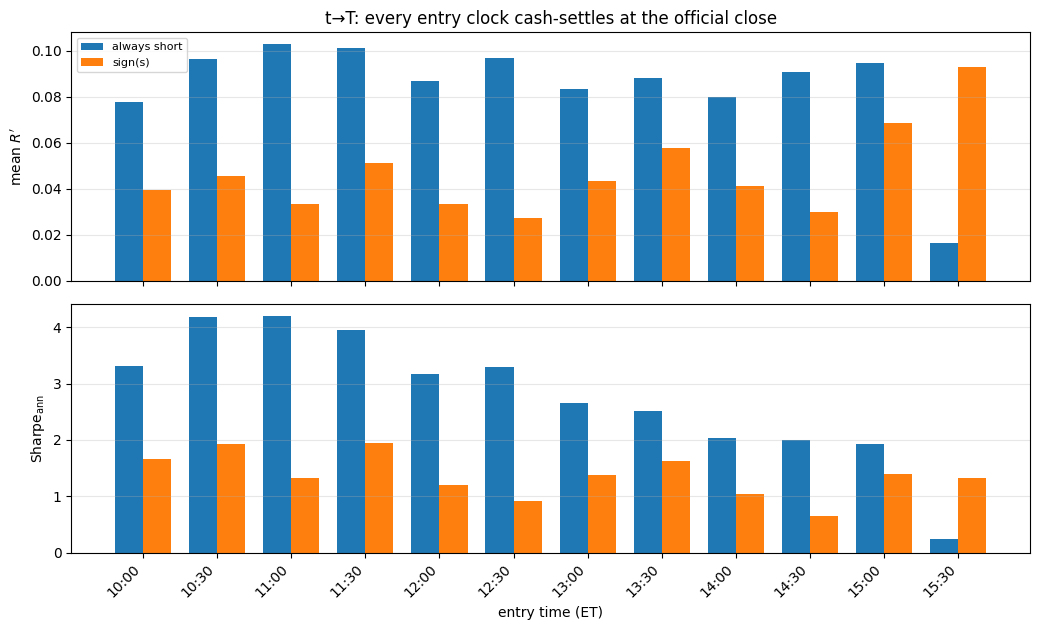

saved CSVs in C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_intraday_holdclose


In [14]:
_q8 = {k: v for k, v in q.items() if k in ("always short", "sign(s)")}  # the two single rules only
clock_rows = []
for hhmm, g in work.groupby("hhmm", sort=True):
    for name, size in _q8.items():
        rp = (size * work["R"]).loc[g.index]
        st = asl.rule_row(rp, size.loc[g.index])
        clock_rows.append({"hhmm": hhmm, "rule": name, **st.to_dict()})
stab = pd.DataFrame(clock_rows)
stab.to_csv(OUT / "rule_by_entry_hhmm.csv", index=False)
print("always short by clock time")
print(stab[stab["rule"] == "always short"][
    ["hhmm", "n", "mean", "t_mean", "Sharpe_ann"]
].to_string(index=False))
print("sign(s) by clock time (window-matched signal)")
print(stab[stab["rule"] == "sign(s)"][
    ["hhmm", "n", "mean", "t_mean", "Sharpe_ann", "pct_buy"]
].to_string(index=False))

hour_rows = []
for hr, g in work.groupby("hour"):
    for name, size in _q8.items():
        rp = (size * work["R"]).loc[g.index]
        st = asl.rule_row(rp, size.loc[g.index])
        hour_rows.append({"hour": int(hr), "rule": name, **st.to_dict()})
htab = pd.DataFrame(hour_rows)
htab.to_csv(OUT / "rule_by_entry_hour.csv", index=False)

_rules = ["always short", "sign(s)"]
_hh = list(stab["hhmm"].drop_duplicates())
_x = np.arange(len(_hh))
_w = 0.38
fig, axes = plt.subplots(2, 1, figsize=(10.5, 6.4), sharex=True)
for i, rule in enumerate(_rules):
    sub = stab[stab["rule"] == rule].set_index("hhmm").reindex(_hh)
    axes[0].bar(_x + (i - 0.5) * _w, sub["mean"].to_numpy(float), _w, label=rule)
    axes[1].bar(_x + (i - 0.5) * _w, sub["Sharpe_ann"].to_numpy(float), _w, label=rule)
for ax, ylab in ((axes[0], "mean $R'$"), (axes[1], r"Sharpe$_{\mathrm{ann}}$")):
    ax.axhline(0, color="k", lw=0.6)
    ax.set_ylabel(ylab)
    ax.grid(axis="y", alpha=0.3)
axes[0].set_title("t→T: every entry clock cash-settles at the official close")
axes[1].set_xticks(_x)
axes[1].set_xticklabels(_hh, rotation=45, ha="right")
axes[1].set_xlabel("entry time (ET)")
axes[0].legend(fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig(OUT / "mean_by_entry_hhmm_as.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close(fig)
print("saved CSVs in", OUT)


## 8b. Forecast QLIKE on this sample (2020--2024)

The book uses the block-diagonal ridge's $\widehat{RV}$ against next-bar
realized variance. QLIKE is $y/f-\log(y/f)-1$ (Patton; lower is better).
The cell scores it on the scored bars only, clock by clock, against two
$F_t$ comparators: the lagged expanding per-clock mean of $RV$ (the same
history that builds $w$), and the implied slice $w_t\mathrm{IV}^{2}_{\mathrm{hr}}h_t$.
A forecast that is fine on QLIKE and still loses on $\mathrm{sign}(s)$ is
not why the daytime Sharpes are small; the slice is.

In [15]:
def _qlike_mean(y, f):
    y = np.asarray(y, float)
    f = np.asarray(f, float)
    m = np.isfinite(y) & np.isfinite(f) & (y > 0) & (f > 0)
    if int(m.sum()) < 2:
        return float("nan"), 0
    r = y[m] / f[m]
    return float(np.mean(r - np.log(r) - 1.0)), int(m.sum())


# lagged per-clock mean of RV, same panel history as w (already in `prof`)
_naive = prof[clocks].expanding(min_periods=63).mean().shift(1)
_mi = pd.MultiIndex.from_arrays([work["date"], work["hhmm"]])
work = work.copy()
work["rv_naive"] = _naive.stack().reindex(_mi).to_numpy()
work["slice"] = work["iv_next30_matched"]

_ql_rows = []
for _hh, _g in work.groupby("hhmm", sort=True):
    _y = _g["rv_raw"]
    for _name, _f in (("ridge", _g["rv_hat"]), ("naive clock mean", _g["rv_naive"]),
                      ("implied slice", _g["slice"])):
        _q, _n = _qlike_mean(_y, _f)
        _ok = np.isfinite(_y) & np.isfinite(_f) & (_y > 0) & (_f > 0)
        _corr = float(pd.Series(_y[_ok]).corr(_f[_ok])) if int(_ok.sum()) > 2 else float("nan")
        _ratio = float(_y[_ok].mean() / _f[_ok].mean()) if int(_ok.sum()) else float("nan")
        _ql_rows.append({"hhmm": _hh, "forecast": _name, "n": _n, "QLIKE": _q,
                         "corr": _corr, "mean RV / mean f": _ratio})
_ql = pd.DataFrame(_ql_rows)
print("QLIKE on scored 2020-2024 bars (block-diagonal ridge vs two F_t comparators)")
print(_ql.pivot(index="hhmm", columns="forecast", values="QLIKE").to_string(float_format=lambda x: f"{x:.4f}"))
print("corr(RV, f)")
print(_ql.pivot(index="hhmm", columns="forecast", values="corr").to_string(float_format=lambda x: f"{x:.3f}"))
print("mean RV / mean f (1 = calibrated)")
print(_ql.pivot(index="hhmm", columns="forecast", values="mean RV / mean f").to_string(float_format=lambda x: f"{x:.3f}"))
for _name in ("ridge", "naive clock mean", "implied slice"):
    _sub = work
    _q, _n = _qlike_mean(_sub["rv_raw"], _sub[{"ridge": "rv_hat", "naive clock mean": "rv_naive",
                                               "implied slice": "slice"}[_name]])
    print(f"pooled {_name:18s} QLIKE {_q:.4f}  n={_n}")
_ql.to_csv(OUT / "forecast_qlike_by_clock_blk2.csv", index=False)

_day = work["hhmm"] != "15:30"
_close = work["hhmm"] == "15:30"
print("ridge QLIKE 10:00-15:00", _qlike_mean(work.loc[_day, "rv_raw"], work.loc[_day, "rv_hat"])[0])
print("ridge QLIKE 15:30      ", _qlike_mean(work.loc[_close, "rv_raw"], work.loc[_close, "rv_hat"])[0])
print("naive QLIKE 10:00-15:00", _qlike_mean(work.loc[_day, "rv_raw"], work.loc[_day, "rv_naive"])[0])
print("naive QLIKE 15:30      ", _qlike_mean(work.loc[_close, "rv_raw"], work.loc[_close, "rv_naive"])[0])


QLIKE on scored 2020-2024 bars (block-diagonal ridge vs two F_t comparators)
forecast  implied slice  naive clock mean  ridge
hhmm                                            
10:00            0.1557            0.6410 0.1607
10:30            0.1725            0.6472 0.1336
11:00            0.1797            0.7011 0.1490
11:30            0.1729            0.7520 0.1318
12:00            0.1906            0.7560 0.1383
12:30            0.1922            0.7809 0.1633
13:00            0.2237            0.7368 0.1684
13:30            0.2225            0.8682 0.1808
14:00            0.2015            0.9109 0.4836
14:30            0.2021            0.9995 0.2324
15:00            0.1521            0.8113 0.1269
15:30            0.1040            0.9011 0.1100
corr(RV, f)
forecast  implied slice  naive clock mean  ridge
hhmm                                            
10:00             0.895            -0.066  0.846
10:30             0.883            -0.121  0.776
11:00             0.773      

## 8c. Confusion matrices: the position against the outcome, clock by clock

One 2×2 per entry clock. Rows: the position the matched signal takes
(**buy** if $s^{\mathrm{m}}_t>0$, **sell** otherwise). Columns: whether
the long straddle's hedged return (§4b) was positive ($R_t>0$, the buy
was right) or not ($R_t\le 0$, the sell was right). Each cell is the
number of days, with its share of that clock's days. The diagonal is
the days the position was right, so **accuracy** = (buy and $R>0$) +
(sell and $R\le 0$), over all days. The **base rate** is the share of
days the long straddle won, with no forecast: a forecast that knew
nothing would buy that often right and sell $1-$ that often right.
Bars without a signal (a censored implied volatility, §5b) are left
out and counted. Midpoint fills, block-diagonal ridge.

bars without a signal, left out: 13 of 10387
matched sign(s), block-diagonal ridge, hedged R (mid); counts are days
         n  buy, R>0  buy, R<=0  sell, R>0  sell, R<=0  accuracy  buy share  base rate P(R>0)  P(R>0 | buy)  P(R<=0 | sell)
hhmm                                                                                                                       
10:00  864       114        189        180         381     0.573      0.351             0.340         0.376           0.679
10:30  865        99        202        173         391     0.566      0.348             0.314         0.329           0.693
11:00  865       116        249        162         338     0.525      0.422             0.321         0.318           0.676
11:30  864       120        215        161         368     0.565      0.388             0.325         0.358           0.696
12:00  866       144        223        176         323     0.539      0.424             0.370         0.392           0.647
12:30  866      

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_intraday_holdclose\confusion_matrix_by_clock.png


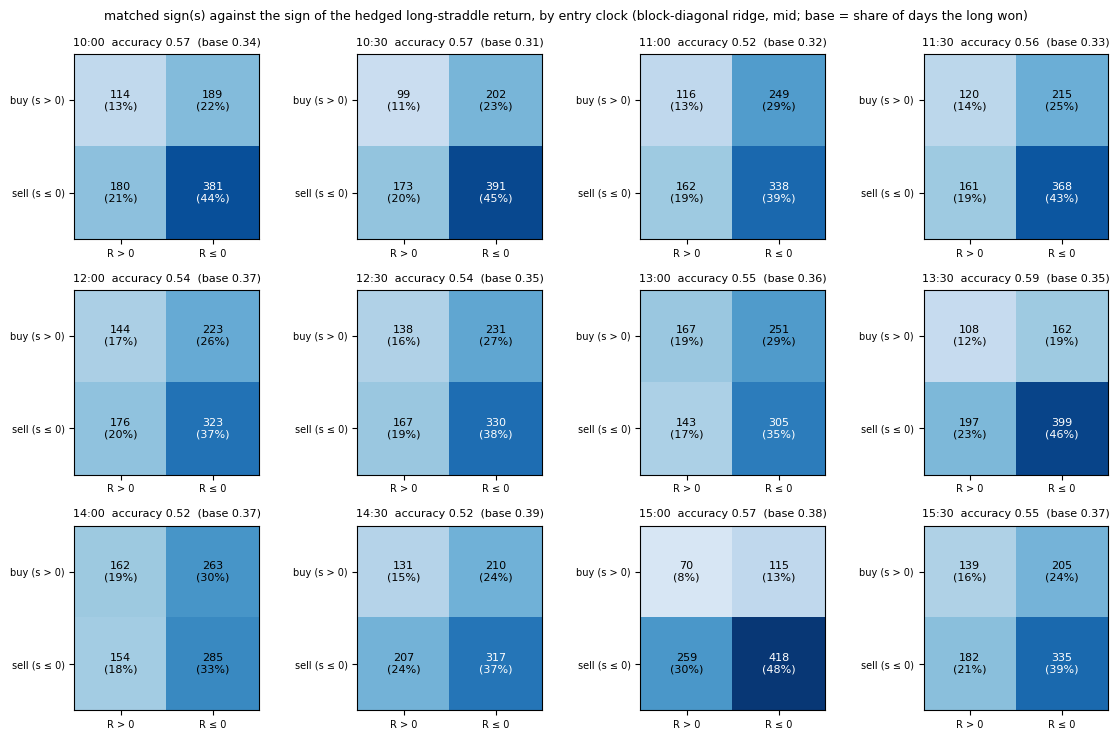

In [16]:
# [cm] position (sign of the matched signal) against outcome (sign of the hedged long R), per entry clock
_ok = np.isfinite(work["s_matched"].to_numpy(float)) & np.isfinite(work["R"].to_numpy(float))
print("bars without a signal, left out:", int((~_ok).sum()), "of", len(work))
_cmw = work.loc[_ok, ["hhmm", "s_matched", "R"]]
_cm_rows = []
for _hhmm, _g in _cmw.groupby("hhmm", sort=True):
    _buy = (_g["s_matched"] > 0).to_numpy(dtype=bool)
    _up = (_g["R"] > 0).to_numpy(dtype=bool)
    _n = len(_g)
    _cm_rows.append({
        "hhmm": _hhmm, "n": _n,
        "buy, R>0": int((_buy & _up).sum()), "buy, R<=0": int((_buy & ~_up).sum()),
        "sell, R>0": int((~_buy & _up).sum()), "sell, R<=0": int((~_buy & ~_up).sum()),
        "accuracy": float(((_buy & _up) | (~_buy & ~_up)).mean()),
        "buy share": float(_buy.mean()), "base rate P(R>0)": float(_up.mean()),
        "P(R>0 | buy)": float(_up[_buy].mean()) if _buy.any() else float("nan"),
        "P(R<=0 | sell)": float((~_up[~_buy]).mean()) if (~_buy).any() else float("nan"),
    })
cmt = pd.DataFrame(_cm_rows).set_index("hhmm")
assert int(cmt[["buy, R>0", "buy, R<=0", "sell, R>0", "sell, R<=0"]].to_numpy().sum()) == int(_ok.sum())
print("matched sign(s), block-diagonal ridge, hedged R (mid); counts are days")
print(cmt.to_string(float_format=lambda x: f"{x:.3f}"))
cmt.to_csv(OUT / "confusion_matrix_by_clock.csv")
print("saved", OUT / "confusion_matrix_by_clock.csv")

_ck = list(cmt.index)
_ncol = 4
_nrow = -(-len(_ck) // _ncol)
fig, axes = plt.subplots(_nrow, _ncol, figsize=(2.9 * _ncol, 2.5 * _nrow))
for ax in axes.ravel()[len(_ck):]:
    ax.set_visible(False)
for ax, c in zip(axes.ravel(), _ck):
    _r = cmt.loc[c]
    mat = np.array([[_r["buy, R>0"], _r["buy, R<=0"]], [_r["sell, R>0"], _r["sell, R<=0"]]], float)
    n = mat.sum()
    ax.imshow(mat, cmap="Blues", vmin=0, vmax=max(n / 2, 1))
    for (i, j), v in np.ndenumerate(mat):
        ax.text(j, i, f"{int(v)}\n({100 * v / n:.0f}%)", ha="center", va="center", fontsize=8,
                color="white" if v > n / 3 else "black")
    ax.set_title(f"{c}  accuracy {_r['accuracy']:.2f}  (base {_r['base rate P(R>0)']:.2f})", fontsize=8)
    ax.set_xticks([0, 1], labels=["R > 0", "R ≤ 0"], fontsize=7)
    ax.set_yticks([0, 1], labels=["buy (s > 0)", "sell (s ≤ 0)"], fontsize=7)
fig.suptitle("matched sign(s) against the sign of the hedged long-straddle return, by entry clock "
             "(block-diagonal ridge, mid; base = share of days the long won)", fontsize=9)
fig.tight_layout()
fig.savefig(OUT / "confusion_matrix_by_clock.png", dpi=130, bbox_inches="tight")
print("saved", OUT / "confusion_matrix_by_clock.png")
display(fig)
plt.close(fig)


## 8d. A rest-of-day forecast fitted on the rest of the day

§5b reaches the rest of the day by stretching the next-bar forecast with the average profile, $\widehat{RV}_t/w_t$. This section replaces the stretch with a forecast of the rest-of-day variance itself, $F^{\mathrm{rem}}_t\approx E_t\big[\sum_{u\ge t}RV_u\big]$ (the bars from $t$ to the 16:00 close), and trades it against the same quoted implied, with no $w$:

$$s^{\mathrm{rem}}_t=F^{\mathrm{rem}}_t-\mathrm{IV}^{2}_{\mathrm{hr},t}\,h_t .$$

**The forecast** (`experiments/multihorizon_ttc.py`, one fit per entry clock, on the block-diagonal ridge of §5):

| | regression for $\log RV^{\mathrm{rem}}_t$ |
|---|---|
| M1 | $a+b\log\widehat{RV}_t$ (the next-bar forecast issued at $t$) |
| M2 | M1 $+\,d\log RV_{\mathrm{open}\to t}$ (realized variance from the open through $t$) |
| M3 | M2 $+\,e\log RV^{\mathrm{rem}}_{t}(\text{previous session})$ |

Each is fit by least squares on the panel's sessions **strictly before** the day (2001 on, at least 63), and the exponentiated fit is multiplied by the mean of realized over forecast on the earlier sessions (a log fit forecasts a geometric mean; the factor moves it to the mean). Every input is known at $t$: the forecast issued at $t$, realized variance through $t$, and earlier sessions. No forecast issued after $t$ enters. Summing the per-bar forecasts issued *during* the hold would look ahead.

**Gates.** (1) The persisted target of the forecast file must equal this notebook's realized variance from $t$ to the close (the panel bars $t,\ldots,15{:}30$ of §5b summed), cell by cell; that fixes the window and the variance units of $F^{\mathrm{rem}}$. The script's default grid ends at the bar that ends at 15:30 and so leaves out the last bar (15:30–16:00); the notebook reads the variant that runs to the close (`--through-close`), and the cell shows the default file is short by exactly that bar. (2) Per clock, the median quoted implied $\mathrm{IV}^2_{\mathrm{hr}}h$ and the median forecasts must be the size of the median realized rest of the day: nearer 1 than the factor $252\times6.5$ that the annualized reading of the vendor number (side question) would put between them. (3) $\mathrm{sign}(s^{\mathrm m})$ and always short, recomputed here, must equal §8's Sharpe ratios and §8c's accuracy at every clock.

**Scope.** Entry clocks 10:00–15:00 on §6's 866 days. At 15:30 the rest of the day is one bar: $s^{\mathrm{rem}}$ and $s^{\mathrm m}$ compare a forecast of the same bar with the same implied ($w=1$), so 15:30 is left out; the cell prints how close the two one-bar forecasts are there. The pooled $\mathrm{sign}(s^{\mathrm m})$ row is therefore over eleven clocks, not §6's twelve.

**Tables.** QLIKE of each rest-of-day forecast against the realized rest of the day; the pooled rule table (daily sums, §6's convention) at the midpoint and at the crossed spread (§7: buy at the ask, sell at the bid, cash-settle); how often $\mathrm{sign}(s^{\mathrm{rem}})$ and $\mathrm{sign}(s^{\mathrm m})$ differ, with the paired Sharpe difference and §7's moving-block bootstrap interval; which way they differ; then per clock the Sharpe ratios, accuracy and buy share (§8c's definitions) and the paired interval.

rest-of-day forecasts: ttc_close_fomc1_forecasts.parquet | 5708 panel days 2001-07-16 -> 2024-04-30 | entry clocks 10:00 .. 15:30
GATE the file's target equals the panel's realized variance from t to the 16:00 close on all 68196 shared day x clock cells (max relative diff 5.6e-16)
the default-grid file (ttc_forecasts.parquet) omits exactly the 15:30-16:00 bar; median share of the rest of the day it misses at 10:00 / 13:00 / 15:00: 9.4% / 21.5% / 54.6%


frame: 9521 bars, 866 days, clocks 10:00 .. 15:00 | every bar has all three rest-of-day forecasts
GATE units: median over days, relative to the median realized rest of the day (1 = same size); every entry within a factor 40 of 1, the annualized reading would sit 1638x off
       implied IV^2 h  RVhat/w (in s^m)  F_rem M1  F_rem M2  F_rem M3
hhmm                                                                 
10:00        1.159000          0.980000  1.083000  1.068000  1.055000
10:30        1.190000          0.995000  1.046000  1.044000  1.077000
11:00        1.251000          1.048000  1.093000  1.089000  1.102000
11:30        1.285000          1.068000  1.080000  1.079000  1.088000
12:00        1.256000          1.102000  1.178000  1.158000  1.153000
12:30        1.272000          1.100000  1.170000  1.167000  1.151000
13:00        1.224000          1.199000  1.295000  1.232000  1.228000
13:30        1.269000          1.020000  1.188000  1.190000  1.195000
14:00        1.250000      


sign(s^rem) minus sign(s^m): share of bars whose sign differs, and the Sharpe difference with its 95% moving-block bootstrap interval (percentile and basic)
                disagree % of bars  dSharpe  pct lo  pct hi  basic lo  basic hi        reading
signal fill                                                                                   
M1     mid                 +10.438   -0.601  -1.109  -0.107    -1.096    -0.094  excludes zero
       crossed             +10.438   -0.573  -1.060  -0.090    -1.055    -0.085  excludes zero
M2     mid                 +15.884   -1.147  -1.817  -0.590    -1.704    -0.477  excludes zero
       crossed             +15.884   -1.032  -1.674  -0.467    -1.597    -0.390  excludes zero
M3     mid                 +17.324   -1.440  -2.141  -0.851    -2.029    -0.739  excludes zero
       crossed             +17.324   -1.318  -1.994  -0.741    -1.895    -0.641  excludes zero

the bars where the signs differ, by direction: the hedged long straddle's mean re


GATE sign(s^m) and always short per clock equal section 8's Sharpes and section 8c's accuracy at every clock
Sharpe_ann by entry clock, midpoint
       short    s^m     M1     M2     M3
hhmm                                    
10:00 +3.319 +1.655 +0.815 +1.242 +0.923
10:30 +4.177 +1.922 +1.245 +1.507 +1.366
11:00 +4.201 +1.328 +1.363 +1.439 +0.749
11:30 +3.953 +1.951 +1.905 +1.796 +1.358
12:00 +3.169 +1.200 +0.519 +0.588 +0.660
12:30 +3.304 +0.914 +0.719 -0.058 +0.097
13:00 +2.658 +1.374 +1.215 +0.474 +0.406
13:30 +2.510 +1.629 +0.748 +0.412 +0.376
14:00 +2.036 +1.043 +0.760 +0.647 +0.134
14:30 +2.003 +0.652 +0.648 +0.591 +0.644
15:00 +1.935 +1.392 +1.290 +0.396 +0.164
Sharpe_ann by entry clock, crossed spread
       short    s^m     M1     M2     M3
hhmm                                    
10:00 +2.292 +0.651 -0.185 +0.240 -0.077
10:30 +3.505 +1.272 +0.597 +0.858 +0.717
11:00 +3.582 +0.727 +0.763 +0.838 +0.150
11:30 +3.332 +1.344 +1.300 +1.190 +0.753
12:00 +2.579 +0.619 -0.061 +0.008

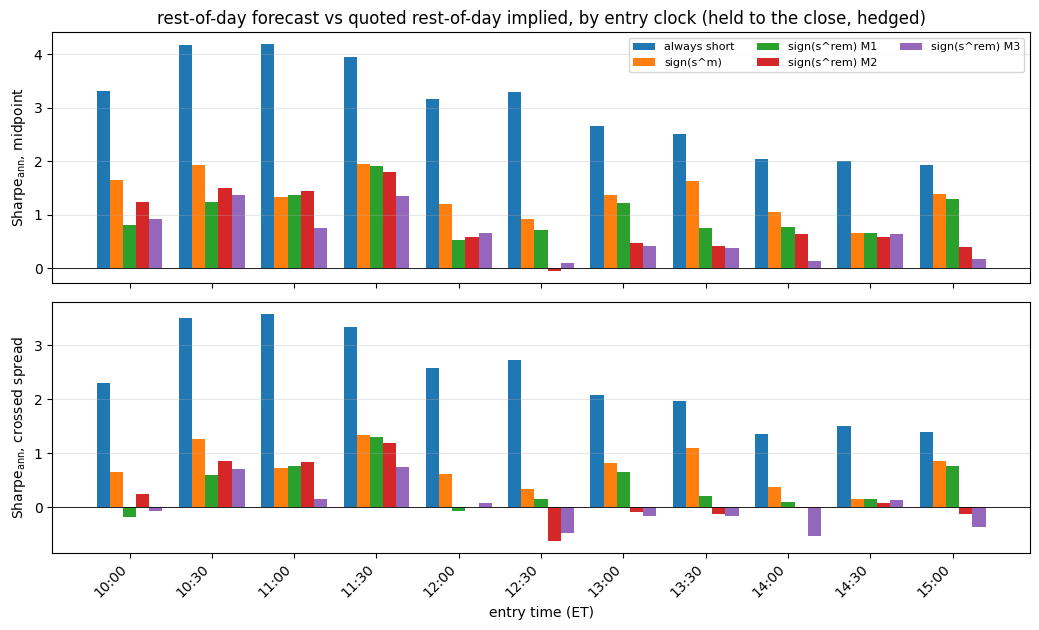

In [17]:
# [frem] the rest-of-day forecast F_rem against the quoted rest-of-day implied, entry clocks 10:00-15:00
FREM_FILE = REPO / "results" / "multihorizon" / "ttc_close_fomc1_forecasts.parquet"
FREM_KEYS = {"M1": "blk2_M1", "M2": "blk2_M2", "M3": "blk2_M3"}
# the file was built from the same block-diagonal ridge export as section 5 (the FOMC panel)
assert YHATS["blk2"].name == "yhat_blk2_fomc1.parquet", YHATS["blk2"].name
fr = pd.read_parquet(FREM_FILE)
fr["date"] = pd.to_datetime(fr["day"])
_frc = sorted(fr["hour"].unique())
print("rest-of-day forecasts:", FREM_FILE.name, "|", fr["date"].nunique(), "panel days",
      fr["date"].min().date(), "->", fr["date"].max().date(), "| entry clocks", _frc[0], "..", _frc[-1])
assert _frc == clocks, "the forecast file's entry clocks are not this notebook's"

# GATE 1 -- target and units. The file's realized target y at clock t must be this notebook's realized
# variance from t to the 16:00 close: the panel's own bars t..15:30 summed (prof, section 5b).
_real = pd.DataFrame({c: prof[clocks[i:]].sum(axis=1, min_count=len(clocks) - i) for i, c in enumerate(clocks)})
_rj = _real.stack().rename_axis(["date", "hour"])
_g1 = pd.concat({"file": fr.set_index(["date", "hour"])["y"], "panel": _rj}, axis=1, join="inner").dropna()
assert np.allclose(_g1["file"], _g1["panel"], rtol=1e-12, atol=0.0), "F_rem's target is not the realized rest of the day"
print(f"GATE the file's target equals the panel's realized variance from t to the 16:00 close on all {len(_g1)} "
      f"shared day x clock cells (max relative diff {float((_g1['file'] / _g1['panel'] - 1).abs().max()):.1e})")
# the script's default grid stops at the bar ending 15:30: its target is short by exactly the 15:30-16:00 bar
_od = pd.read_parquet(REPO / "results" / "multihorizon" / "ttc_forecasts.parquet")
_od["date"] = pd.to_datetime(_od["day"])
_g0 = pd.concat({"default": _od.set_index(["date", "hour"])["y"], "panel": _rj}, axis=1, join="inner").dropna()
_last = prof["15:30"].reindex(_g0.index.get_level_values("date")).to_numpy()
assert np.allclose(_g0["default"].to_numpy() + _last, _g0["panel"].to_numpy(), rtol=1e-12, atol=0.0)
_share = pd.Series(_last / _g0["panel"].to_numpy(), index=_g0.index.get_level_values("hour"))
print("the default-grid file (ttc_forecasts.parquet) omits exactly the 15:30-16:00 bar; median share of the rest "
      "of the day it misses at 10:00 / 13:00 / 15:00:",
      " / ".join(f"{float(_share.loc[c].median()):.1%}" for c in ("10:00", "13:00", "15:00")))

# the frame: section 6's bars and days at the clocks where more than one bar is left
fw = work[work["hhmm"] != clocks[-1]].copy()
_key = pd.MultiIndex.from_arrays([fw["date"], fw["hhmm"]])
_fr = fr.set_index(["date", "hour"])
for _k, _col in FREM_KEYS.items():
    fw["F_" + _k] = _fr[_col].reindex(_key).to_numpy()
    assert bool(np.isfinite(fw["F_" + _k]).all()), f"a scored bar has no {_k} rest-of-day forecast"
fw["rv_rem"] = _rj.reindex(_key).to_numpy()
fw["F_profile"] = fw["rv_hat"] / fw["w_slice"]           # the rest-of-day forecast inside s^m
fw["iv_rem"] = fw["iv_var_raw"] * fw["h_rem"]             # IV_hr^2 x hours to the close: quoted, not allocated
for _k in FREM_KEYS:
    fw["s_rem_" + _k] = fw["F_" + _k] - fw["iv_rem"]
print("frame:", len(fw), "bars,", fw["date"].nunique(), "days, clocks", fw["hhmm"].min(), "..", fw["hhmm"].max(),
      "| every bar has all three rest-of-day forecasts")

# GATE 2 -- units of the implied side. Per clock, the quoted rest-of-day implied, the rest-of-day forecasts and
# the realized rest of the day must be the same size. The one alternative reading of the vendor number
# (annualized, side question) moves the implied by the factor 252 x 6.5; every median ratio must sit closer to 1
# than to that factor on a log scale.
_med = fw.groupby("hhmm")[["rv_rem", "iv_rem", "F_profile"] + ["F_" + k for k in FREM_KEYS]].median()
_lr = np.log(_med.drop(columns="rv_rem").div(_med["rv_rem"], axis=0))
_half = 0.5 * np.log(252.0 * 6.5)
assert bool((_lr.abs() < _half).all().all()), "a rest-of-day variance is off the realized scale"
print("GATE units: median over days, relative to the median realized rest of the day (1 = same size); "
      f"every entry within a factor {float(np.exp(_half)):.0f} of 1, the annualized reading would sit {252 * 6.5:.0f}x off")
print(_med.drop(columns="rv_rem").div(_med["rv_rem"], axis=0).rename(columns={
    "iv_rem": "implied IV^2 h", "F_profile": "RVhat/w (in s^m)", "F_M1": "F_rem M1", "F_M2": "F_rem M2",
    "F_M3": "F_rem M3"}).round(3).to_string())

# at 15:30 the rest of the day is one bar: F_rem and RVhat forecast the same bar, IV^2 h is the deck's IV^2/2
_c15 = work[work["hhmm"] == clocks[-1]]
_f15 = _fr["blk2_M1"].reindex(pd.MultiIndex.from_arrays([_c15["date"], _c15["hhmm"]])).to_numpy()
_ok15 = np.isfinite(_c15["s_matched"].to_numpy(float)) & np.isfinite(_f15)
_agree15 = float((np.sign(_f15 - _c15["iv_var_raw"].to_numpy(float) * 0.5) == np.sign(_c15["s_matched"].to_numpy(float)))[_ok15].mean())
print(f"15:30, one bar left: median F_rem M1 / RVhat {float(np.median(_f15[_ok15] / _c15['rv_hat'].to_numpy(float)[_ok15])):.3f}; "
      f"sign(F_rem M1 - IV^2/2) = sign(s^m) on {_agree15:.1%} of days. The 15:30 bar is left out below: there the "
      "rest-of-day signal and s^m compare the same one-bar forecast with the same implied")

# QLIKE of the rest-of-day forecasts against the realized rest of the day, on this frame
_ql_rem = {}
for _nm, _col in (("RVhat/w (in s^m)", "F_profile"), ("F_rem M1", "F_M1"), ("F_rem M2", "F_M2"), ("F_rem M3", "F_M3")):
    _ql_rem[_nm] = fw.groupby("hhmm").apply(lambda g, c=_col: _qlike_mean(g["rv_rem"], g[c])[0], include_groups=False)
_ql_rem = pd.DataFrame(_ql_rem)
_ql_rem.loc["pooled"] = [_qlike_mean(fw["rv_rem"], fw[c])[0] for c in ("F_profile", "F_M1", "F_M2", "F_M3")]
print("QLIKE of the rest-of-day forecast against the realized rest of the day (lower is better)")
print(_ql_rem.to_string(float_format=lambda x: f"{x:.4f}"))

# rules: flat (q = 0) where the implied quote is censored -- the same bars for every signal (asserted)
def _pos(s):
    s = np.asarray(s, float)
    return pd.Series(np.where(np.isfinite(s), np.where(s > 0, 1.0, -1.0), 0.0), index=fw.index)


rem_rules = {"always short": pd.Series(-1.0, index=fw.index), "sign(s^m)": _pos(fw["s_matched"])}
for _k in FREM_KEYS:
    rem_rules[f"sign(s^rem) {_k}"] = _pos(fw["s_rem_" + _k])
    assert bool((np.isfinite(fw["s_rem_" + _k]) == np.isfinite(fw["s_matched"])).all())
_sig = np.isfinite(fw["s_matched"].to_numpy(float))
print("bars with no signal (censored implied, flat in every sign rule):", int((~_sig).sum()))

# per-bar P&L at the midpoint and at the crossed spread (section 7's _at_spread: buy at the ask, sell at the
# bid, cash-settle), on the full work index with q = 0 at 15:30, so the daily sums are over 10:00-15:00
_bar_mid, _bar_x = {}, {}
for _nm, _qq in rem_rules.items():
    _qf = pd.Series(0.0, index=work.index)
    _qf.loc[fw.index] = _qq
    _pts, _nc, _nu = _at_spread(_qf.to_numpy(dtype=float))
    assert _nu == 0, "a bar has no tradeable fill"
    _bar_mid[_nm] = (_qf * work["R"]).loc[fw.index]
    _bar_x[_nm] = (_pts / work["entry"]).loc[fw.index]
_dmid = {k: v.groupby(fw["date"]).sum() for k, v in _bar_mid.items()}
_dx = {k: v.groupby(fw["date"]).sum() for k, v in _bar_x.items()}

_pool = []
for _nm, _qq in rem_rules.items():
    _d, _e = _dmid[_nm], _dx[_nm]
    _pool.append({"rule": _nm, "n": len(_qq), "n_days": len(_d), "mean_daily": float(_d.mean()),
                  "t_mean": float(_d.mean() / _d.std(ddof=1) * np.sqrt(len(_d))), "Sharpe_ann": _sh(_d),
                  "Sharpe crossed-spread": _sh(_e), "mean/day crossed-spread": float(_e.mean()),
                  "pct_buy": 100.0 * float((_qq > 0).mean())})
rem_tab = pd.DataFrame(_pool).set_index("rule")
print()
print("pooled, entry clocks 10:00-15:00 (15:30 left out, see above); daily sums, block-diagonal ridge")
print(rem_tab.to_string(float_format=lambda x: f"{x:.3f}"))
rem_tab.to_csv(OUT / "rule_table_srem_blk2.csv")

# paired Sharpe difference, sign(s^rem) minus sign(s^m), same days (section 7's bootstrap)
_dif = []
for _k in FREM_KEYS:
    _nm = f"sign(s^rem) {_k}"
    _dis = (np.sign(fw["s_rem_" + _k]) != np.sign(fw["s_matched"])).to_numpy()[_sig]
    for _fill, _D in (("mid", _dmid), ("crossed", _dx)):
        _ci = _boot_dsharpe(_D[_nm].to_numpy(), _D["sign(s^m)"].to_numpy())
        _dif.append({"signal": _k, "fill": _fill, "disagree % of bars": 100.0 * float(_dis.mean()),
                     "dSharpe": _sh(_D[_nm]) - _sh(_D["sign(s^m)"]),
                     "pct lo": _ci["pct_lo"], "pct hi": _ci["pct_hi"], "basic lo": _ci["basic_lo"],
                     "basic hi": _ci["basic_hi"], "reading": _interval_reading(_ci)})
rem_dif = pd.DataFrame(_dif).set_index(["signal", "fill"])
print()
print("sign(s^rem) minus sign(s^m): share of bars whose sign differs, and the Sharpe difference with its 95% "
      "moving-block bootstrap interval (percentile and basic)")
print(rem_dif.to_string(float_format=lambda x: f"{x:+.3f}"))
rem_dif.to_csv(OUT / "srem_vs_sm_dsharpe.csv")

# where the two signs differ: which way, and what the hedged long straddle returned on those bars
_sigS = np.isfinite(fw["s_matched"])
_dis_rows = []
for _k in FREM_KEYS:
    for _lab, _m in (("s^rem buys, s^m sells", (fw["s_rem_" + _k] > 0) & (fw["s_matched"] <= 0) & _sigS),
                     ("s^rem sells, s^m buys", (fw["s_rem_" + _k] <= 0) & (fw["s_matched"] > 0) & _sigS)):
        _dis_rows.append({"signal": _k, "where they differ": _lab, "bars": int(_m.sum()),
                          "mean R of the long": float(fw.loc[_m, "R"].mean()),
                          "share with R > 0": float((fw.loc[_m, "R"] > 0).mean())})
print()
print("the bars where the signs differ, by direction: the hedged long straddle's mean return there "
      "(the side that bought earns it, the side that sold earns minus it)")
print(pd.DataFrame(_dis_rows).set_index(["signal", "where they differ"]).to_string(float_format=lambda x: f"{x:+.3f}"))

# per clock: Sharpe (mid, crossed), accuracy, disagreement and the paired interval at the midpoint
_pc = []
for _c, _g in fw.groupby("hhmm", sort=True):
    _row = {"hhmm": _c, "n": len(_g)}
    _up = (_g["R"] > 0).to_numpy()
    _s = np.isfinite(_g["s_matched"].to_numpy(float))
    for _nm, _qq in rem_rules.items():
        _row[f"Sharpe {_nm}"] = _sh(_bar_mid[_nm].loc[_g.index])
        _row[f"Sharpe crossed {_nm}"] = _sh(_bar_x[_nm].loc[_g.index])
        if _nm != "always short":
            _b = (_qq.loc[_g.index] > 0).to_numpy()
            _row[f"accuracy {_nm}"] = float(((_b & _up) | (~_b & ~_up))[_s].mean())
            _row[f"buy % {_nm}"] = 100.0 * float(_b[_s].mean())
    for _k in FREM_KEYS:
        _row[f"disagree % {_k}"] = 100.0 * float((np.sign(_g["s_rem_" + _k]) != np.sign(_g["s_matched"])).to_numpy()[_s].mean())
        _ci = _boot_dsharpe(_bar_mid[f"sign(s^rem) {_k}"].loc[_g.index].to_numpy(),
                            _bar_mid["sign(s^m)"].loc[_g.index].to_numpy())
        _row[f"dSharpe {_k}"] = _row[f"Sharpe sign(s^rem) {_k}"] - _row["Sharpe sign(s^m)"]
        _row[f"dSharpe {_k} 95% pct"] = f"[{_ci['pct_lo']:+.2f}, {_ci['pct_hi']:+.2f}]"
    _pc.append(_row)
rem_clk = pd.DataFrame(_pc).set_index("hhmm")
rem_clk.to_csv(OUT / "srem_by_clock_blk2.csv")

# GATES against the tables above: sign(s^m) here is section 8's and section 8c's rule, bar for bar
_s8 = stab[stab["rule"] == "sign(s)"].set_index("hhmm")["Sharpe_ann"].reindex(rem_clk.index)
assert np.allclose(rem_clk["Sharpe sign(s^m)"], _s8, rtol=0, atol=1e-12), "sign(s^m) per clock differs from section 8"
_a8 = stab[stab["rule"] == "always short"].set_index("hhmm")["Sharpe_ann"].reindex(rem_clk.index)
assert np.allclose(rem_clk["Sharpe always short"], _a8, rtol=0, atol=1e-12), "always short per clock differs from section 8"
assert np.allclose(rem_clk["accuracy sign(s^m)"], cmt["accuracy"].reindex(rem_clk.index), rtol=0, atol=1e-12), \
    "sign(s^m) accuracy differs from section 8c"
print()
print("GATE sign(s^m) and always short per clock equal section 8's Sharpes and section 8c's accuracy at every clock")

_rn = {"always short": "short", "sign(s^m)": "s^m", "sign(s^rem) M1": "M1", "sign(s^rem) M2": "M2", "sign(s^rem) M3": "M3"}
print("Sharpe_ann by entry clock, midpoint")
print(rem_clk[[f"Sharpe {k}" for k in rem_rules]].rename(columns=lambda c: _rn[c[len("Sharpe "):]])
      .to_string(float_format=lambda x: f"{x:+.3f}"))
print("Sharpe_ann by entry clock, crossed spread")
print(rem_clk[[f"Sharpe crossed {k}" for k in rem_rules]].rename(columns=lambda c: _rn[c[len("Sharpe crossed "):]])
      .to_string(float_format=lambda x: f"{x:+.3f}"))
print("accuracy (position right about the sign of the hedged long R) and buy share, by entry clock")
_acc = rem_clk[[f"accuracy {k}" for k in list(rem_rules)[1:]]].rename(columns=lambda c: "acc " + _rn[c[len("accuracy "):]])
_buy = rem_clk[[f"buy % {k}" for k in list(rem_rules)[1:]]].rename(columns=lambda c: "buy% " + _rn[c[len("buy % "):]])
print(pd.concat([_acc, _buy], axis=1).to_string(float_format=lambda x: f"{x:.3f}" if abs(x) < 1.5 else f"{x:.1f}"))
print("sign(s^rem) against sign(s^m) by entry clock: % of days the sign differs, Sharpe difference at the midpoint, "
      "95% percentile interval")
_dcols = []
for _k in FREM_KEYS:
    _dcols += [f"disagree % {_k}", f"dSharpe {_k}", f"dSharpe {_k} 95% pct"]
print(rem_clk[_dcols].to_string(float_format=lambda x: f"{x:+.2f}"))

_rules_fig = list(rem_rules)
_x = np.arange(len(rem_clk))
_w = 0.8 / len(_rules_fig)
fig, axes = plt.subplots(2, 1, figsize=(10.5, 6.4), sharex=True)
for i, _nm in enumerate(_rules_fig):
    axes[0].bar(_x + (i - (len(_rules_fig) - 1) / 2) * _w, rem_clk[f"Sharpe {_nm}"].to_numpy(float), _w, label=_nm)
    axes[1].bar(_x + (i - (len(_rules_fig) - 1) / 2) * _w, rem_clk[f"Sharpe crossed {_nm}"].to_numpy(float), _w, label=_nm)
for ax, ylab in ((axes[0], r"Sharpe$_{\mathrm{ann}}$, midpoint"), (axes[1], r"Sharpe$_{\mathrm{ann}}$, crossed spread")):
    ax.axhline(0, color="k", lw=0.6)
    ax.set_ylabel(ylab)
    ax.grid(axis="y", alpha=0.3)
axes[0].set_title("rest-of-day forecast vs quoted rest-of-day implied, by entry clock (held to the close, hedged)")
axes[1].set_xticks(_x)
axes[1].set_xticklabels(list(rem_clk.index), rotation=45, ha="right")
axes[1].set_xlabel("entry time (ET)")
axes[0].legend(fontsize=8, loc="upper right", ncol=3)
fig.tight_layout()
fig.savefig(OUT / "srem_by_entry_hhmm.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close(fig)


**Reading §8d.**

- **Units.** The forecast file's target equals this notebook's realized rest of the day on all 68,196 shared day $\times$ clock cells (largest relative difference $5.6\times10^{-16}$). The default grid's target misses the 15:30–16:00 bar, a median 9.4% of the rest of the day at 10:00 and 54.6% at 15:00. Median quoted implied $\mathrm{IV}^2_{\mathrm{hr}}h$ is 1.16–1.33 times the median realized rest of the day across clocks; median $F^{\mathrm{rem}}$ (M1) is 1.05–1.29 times it; median $\widehat{RV}/w$ is 0.93–1.20 times it.
- **As forecasts of the rest of the day** no fitted forecast beats the stretch on this sample: pooled QLIKE is 0.2018 for $\widehat{RV}/w$ against 0.2093 (M1), 0.2132 (M2) and 0.2009 (M3). M3 is ahead at six clocks (most at 10:00, 0.1467 against 0.1628, and at 15:00, 0.1163 against 0.1370) and behind at five (most at 14:00, 0.3040 against 0.2767).
- **As a trade the fitted forecast is worse.** Pooled over 10:00–15:00, $\mathrm{sign}(s^{\mathrm m})$ has Sharpe 2.30 at the midpoint and 1.25 at the crossed spread; $\mathrm{sign}(s^{\mathrm{rem}})$ has 1.70 / 0.68 (M1), 1.15 / 0.22 (M2) and 0.86 / $-0.07$ (M3); always short has 3.38 / 2.65. The signs differ on 10.4% (M1), 15.9% (M2) and 17.3% (M3) of bars. The paired Sharpe difference is $-0.60$ for M1 at the midpoint (95% percentile interval $[-1.11,-0.11]$, basic $[-1.10,-0.09]$), and every interval, for all three at both fills, excludes zero.
- **Where they differ.** Most disagreements are $s^{\mathrm{rem}}$ buying where $s^{\mathrm m}$ sells: 875 of 993 bars for M1, 1,287 of 1,648 for M3. On those bars the hedged long straddle lost on average (mean $R$ $-0.080$ for M1, $-0.118$ for M3; $R>0$ on about a third of them), so the extra buys cost money. $F^{\mathrm{rem}}$ sits higher against the implied than $\widehat{RV}/w$ (the medians above), and the sign rule buys 46.6% of bars with M1 against 38.6% with $s^{\mathrm m}$.
- **By clock** no clock has $\mathrm{sign}(s^{\mathrm{rem}})$ ahead with an interval that excludes zero; the largest point gain is $+0.11$ (M2 at 11:00). M1 is behind with the interval excluding zero at 10:00, 10:30 and 12:00. $\mathrm{sign}(s^{\mathrm m})$ is at least as accurate as all three at nine of the eleven clocks (the exceptions are M2 at 11:00, 0.526 against 0.525, and M3 at 14:30, 0.520 against 0.518).

On these 866 days a rest-of-day forecast fitted on the rest of the day does not improve the hold-to-close signal: it forecasts the rest of the day no better than the profile-stretched next-bar forecast, and, sitting higher against the implied, it buys more often, and the extra buys lose on average.

## 9. Buy-signal fingerprint (day $\times$ clock)

Each column is one expiration day, each row one 30-min clock. The colour is the position the window-matched signal takes for that bar: blue buy ($s^{\mathrm{m}}_t>0$), red short ($s^{\mathrm{m}}_t\le 0$), grey flat (no implied quote: the solver's bracket node was censored). The §8 tables average this grid along each row.

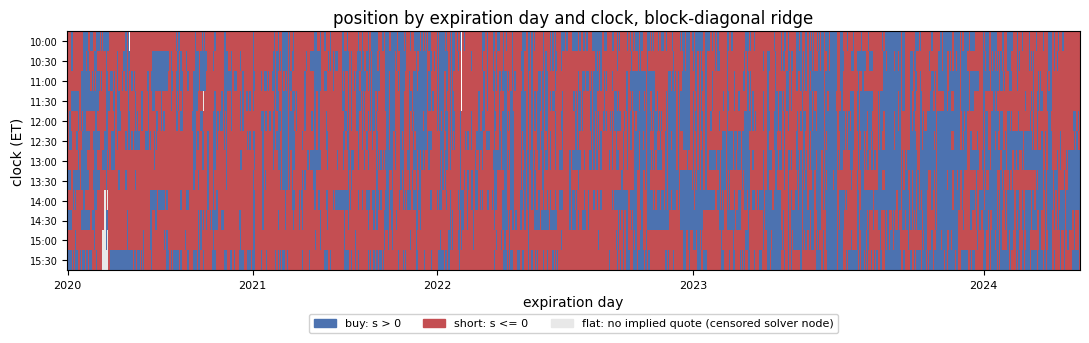

buy share by year (%)
date
2020    27.100000
2021    32.200000
2022    36.100000
2023    50.300000
2024    45.500000


mean same-stance run length within a day (bars): 4.13


In [18]:
grid = work.assign(qsign=pos_m.fillna(0.0)).pivot_table(
    index="hhmm", columns="date", values="qsign", aggfunc="first"
)
grid = grid.sort_index()

from matplotlib.colors import BoundaryNorm, ListedColormap
cmap = ListedColormap(["#c44e52", "#e8e8e8", "#4c72b0"])
norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5], cmap.N)
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.imshow(grid.to_numpy(), aspect="auto", cmap=cmap, norm=norm, interpolation="none")
ax.set_yticks(range(len(grid.index)), grid.index, fontsize=7)
yrs = pd.DatetimeIndex(grid.columns).year
ticks = [int(np.argmax(yrs == y)) for y in sorted(set(yrs))]
ax.set_xticks(ticks, sorted(set(yrs)), fontsize=8)
ax.set_xlabel("expiration day")
ax.set_ylabel("clock (ET)")
ax.set_title("position by expiration day and clock, block-diagonal ridge")
from matplotlib.patches import Patch
ax.legend(
    handles=[Patch(color="#4c72b0", label="buy: s > 0"), Patch(color="#c44e52", label="short: s <= 0"),
             Patch(color="#e8e8e8", label="flat: no implied quote (censored solver node)")],
    fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3, framealpha=0.9,
)
fig.tight_layout()
fig.savefig(OUT / "buy_fingerprint_day_clock.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close(fig)

sgn = pos_m.fillna(0.0)
by_year = work.assign(buy=(sgn > 0)).groupby(work["date"].dt.year)["buy"].mean() * 100.0
print("buy share by year (%)")
print(by_year.round(1).to_string())
runs = (
    work.assign(qsign=sgn)
    .groupby("date")["qsign"]
    .apply(lambda s: (s != s.shift()).cumsum().value_counts().mean())
)
print("mean same-stance run length within a day (bars):", round(float(runs.mean()), 2))
